<a href="https://colab.research.google.com/github/manushi0304/CapstoneProject/blob/main/MobilenetV3_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -*- coding: utf-8 -*-
"""Another copy of Yet another copy of claudecode.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1dX-mqUde_MyBi67EMhPPnQsI_bkNyeMK
"""

# Colab cell 1: Runtime setup
# (Run this cell first)
# If you're not in Colab you can still run; make sure PyTorch + torchvision are installed.
!nvidia-smi || true

Mon Apr 20 04:06:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:

# Colab cell 2: Install optional helper packages
# thop for FLOPs counting. If already installed, pip will be fast.
!pip install -q thop
!pip install -q onnx
!pip install -q onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 15.9 MB/s eta 0:00:00


In [ ]:
"""
Cell 1: Configuration and Setup
================================
Centralized configuration for the NAS+Pruning pipeline.
"""

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, SubsetRandomSampler
import torchvision
from torchvision import transforms, datasets, models
import torch.nn.utils.prune as prune
from thop import profile
import matplotlib.pyplot as plt
import time
import copy
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')




In [ ]:
# ============================================================================
# CONFIGURATION CLASS
# ============================================================================

class Config:
    """Centralized configuration for reproducibility and easy tuning."""

    # Hardware
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    NUM_WORKERS = 2
    PIN_MEMORY = True

    # Reproducibility
    SEED = 42

    # Data
    DATA_DIR = './data'
    BATCH_SIZE = 128
    NUM_CLASSES = 10
    VALIDATION_SPLIT = 0.2  # 20% of training data for validation

    # Training - Baseline
    BASELINE_EPOCHS = 50
    BASELINE_LR = 0.1
    BASELINE_MOMENTUM = 0.9
    BASELINE_WEIGHT_DECAY = 5e-4
    BASELINE_MILESTONES = [25, 40]  # LR decay at these epochs
    BASELINE_GAMMA = 0.1

    # Training - Fine-tuning after pruning
    # CHANGED: SGD → Adam, more epochs, lower LR, cosine decay (no step params needed)
    FINETUNE_EPOCHS       = 50     # was 30  — pruned models need more recovery time
    FINETUNE_LR           = 1e-3   # was 0.01 — Adam works best with smaller LR
    FINETUNE_WEIGHT_DECAY = 1e-4   # was 5e-4 — less regularization post-pruning
    # FINETUNE_MOMENTUM, FINETUNE_STEP_SIZE, FINETUNE_GAMMA removed — not used with Adam+Cosine

    # Pruning
    # CHANGED: 0.3 → 0.5 for ~35-40% param reduction (was only giving 17%)
    PRUNE_AMOUNT         = 0.5   # was 0.3 — 50% cuts more expansion channels
    PRUNE_SKIP_DEPTHWISE = True  # Skip depthwise convolutions
    PRUNE_SKIP_FIRST_LAST = True  # Skip first and last layers

    # DARTS Search
    DARTS_INIT_CHANNELS = 16
    DARTS_LAYERS = 6
    DARTS_SEARCH_EPOCHS = 50
    DARTS_SEARCH_BATCHES_PER_EPOCH = 50  # Limit batches per epoch for speed
    DARTS_WEIGHT_LR = 0.025
    DARTS_WEIGHT_MOMENTUM = 0.9
    DARTS_WEIGHT_DECAY = 3e-4
    DARTS_ARCH_LR = 3e-4
    DARTS_ARCH_WEIGHT_DECAY = 1e-3

    # DARTS Final Training
    DARTS_TRAIN_EPOCHS = 50
    DARTS_TRAIN_LR = 0.025
    DARTS_TRAIN_MOMENTUM = 0.9
    DARTS_TRAIN_WEIGHT_DECAY = 3e-4
    DARTS_TRAIN_MILESTONES = [25, 40]
    DARTS_TRAIN_GAMMA = 0.1

    # DARTS + Pruning Combined
    DARTS_PRUNE_AMOUNT = 0.3
    DARTS_FINETUNE_EPOCHS = 30
    DARTS_FINETUNE_LR = 0.01
    DARTS_FINETUNE_WEIGHT_DECAY = 1e-4

    # Evaluation
    INFERENCE_WARMUP_BATCHES = 3
    INFERENCE_MEASURE_BATCHES = 20

    # Paths
    MODEL_DIR = './models'
    RESULTS_DIR = './results'

    @classmethod
    def print_config(cls):
        """Print all configuration parameters."""
        print("=" * 70)
        print("CONFIGURATION")
        print("=" * 70)
        for attr in dir(cls):
            if not attr.startswith('_') and attr.isupper():
                print(f"{attr:30s}: {getattr(cls, attr)}")
        print("=" * 70)

In [ ]:
# ============================================================================
# REPRODUCIBILITY SETUP
# ============================================================================

def set_seed(seed: int = 42):
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✅ Random seed set to {seed}")

In [ ]:
# ============================================================================
# DIRECTORY SETUP
# ============================================================================

def setup_directories():
    """Create necessary directories."""
    os.makedirs(Config.MODEL_DIR, exist_ok=True)
    os.makedirs(Config.RESULTS_DIR, exist_ok=True)
    print(f"✅ Directories created: {Config.MODEL_DIR}, {Config.RESULTS_DIR}")

In [ ]:
# ============================================================================
# INITIALIZE
# ============================================================================

if __name__ == "__main__":
    Config.print_config()
    set_seed(Config.SEED)
    setup_directories()
    print(f"✅ Using device: {Config.DEVICE}")

#2
from typing import Tuple
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import transforms, datasets
import numpy as np


# ============================================================================
# DATA TRANSFORMS
# ============================================================================

def get_transforms() -> Tuple[transforms.Compose, transforms.Compose]:
    """
    Get data augmentation transforms for CIFAR-10.

    Returns:
        train_transform: Augmentation for training
        test_transform: Normalization only for testing
    """
    # CIFAR-10 normalization constants
    CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
    CIFAR_STD = (0.2023, 0.1994, 0.2010)

    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
    ])

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
    ])

    return train_transform, test_transform


# ============================================================================
# DATASET LOADING
# ============================================================================

def load_cifar10(config) -> Tuple:
    """
    Load CIFAR-10 with proper train/validation split.

    Args:
        config: Configuration object

    Returns:
        trainloader: Training data loader
        validloader: Validation data loader (from training set)
        testloader: Test data loader
        train_dataset: Full training dataset
        test_dataset: Test dataset
    """
    train_transform, test_transform = get_transforms()

    # Load datasets
    train_dataset = datasets.CIFAR10(
        root=config.DATA_DIR,
        train=True,
        download=True,
        transform=train_transform
    )

    test_dataset = datasets.CIFAR10(
        root=config.DATA_DIR,
        train=False,
        download=True,
        transform=test_transform
    )

    # Create train/validation split for DARTS
    num_train = len(train_dataset)
    indices = list(range(num_train))
    split = int(np.floor(config.VALIDATION_SPLIT * num_train))

    # Shuffle indices
    np.random.seed(config.SEED)
    np.random.shuffle(indices)

    train_idx, valid_idx = indices[split:], indices[:split]

    # Create samplers
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)

    # Create data loaders
    trainloader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        sampler=train_sampler,
        num_workers=config.NUM_WORKERS,
        pin_memory=config.PIN_MEMORY
    )

    validloader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        sampler=valid_sampler,
        num_workers=config.NUM_WORKERS,
        pin_memory=config.PIN_MEMORY
    )

    testloader = DataLoader(
        test_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=config.NUM_WORKERS,
        pin_memory=config.PIN_MEMORY
    )

    print(f"✅ CIFAR-10 loaded:")
    print(f"   Training samples: {len(train_idx)}")
    print(f"   Validation samples: {len(valid_idx)}")
    print(f"   Test samples: {len(test_dataset)}")

    return trainloader, validloader, testloader, train_dataset, test_dataset


# ============================================================================
# UTILITY: FULL TRAINING LOADER (NO VALIDATION SPLIT)
# ============================================================================

def get_full_trainloader(train_dataset, config) -> DataLoader:
    """
    Get a data loader for the full training set (for final training).

    Args:
        train_dataset: Training dataset
        config: Configuration object

    Returns:
        DataLoader for full training set
    """
    return DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=True,
        num_workers=config.NUM_WORKERS,
        pin_memory=config.PIN_MEMORY
    )


CONFIGURATION
BASELINE_EPOCHS               : 50
BASELINE_GAMMA                : 0.1
BASELINE_LR                   : 0.1
BASELINE_MILESTONES           : [25, 40]
BASELINE_MOMENTUM             : 0.9
BASELINE_WEIGHT_DECAY         : 0.0005
BATCH_SIZE                    : 128
DARTS_ARCH_LR                 : 0.0003
DARTS_ARCH_WEIGHT_DECAY       : 0.001
DARTS_FINETUNE_EPOCHS         : 30
DARTS_FINETUNE_LR             : 0.01
DARTS_FINETUNE_WEIGHT_DECAY   : 0.0001
DARTS_INIT_CHANNELS           : 16
DARTS_LAYERS                  : 6
DARTS_PRUNE_AMOUNT            : 0.3
DARTS_SEARCH_BATCHES_PER_EPOCH: 50
DARTS_SEARCH_EPOCHS           : 50
DARTS_TRAIN_EPOCHS            : 50
DARTS_TRAIN_GAMMA             : 0.1
DARTS_TRAIN_LR                : 0.025
DARTS_TRAIN_MILESTONES        : [25, 40]
DARTS_TRAIN_MOMENTUM          : 0.9
DARTS_TRAIN_WEIGHT_DECAY      : 0.0003
DARTS_WEIGHT_DECAY            : 0.0003
DARTS_WEIGHT_LR               : 0.025
DARTS_WEIGHT_MOMENTUM         : 0.9
DATA_DIR                  

In [ ]:
# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Removed: from cell_01_config_setup import Config, set_seed
    # Config and set_seed are already available in the global scope
    # from previous cell execution.

    set_seed(Config.SEED)
    trainloader, validloader, testloader, train_dataset, test_dataset = load_cifar10(Config)

    # Verify data loading
    images, labels = next(iter(trainloader))
    print(f"✅ Batch shape: {images.shape}, Labels: {labels.shape}")
    print(f"✅ Image range: [{images.min():.2f}, {images.max():.2f}]")

✅ Random seed set to 42


100%|██████████| 170M/170M [00:06<00:00, 25.7MB/s]


✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000
✅ Batch shape: torch.Size([128, 3, 32, 32]), Labels: torch.Size([128])
✅ Image range: [-2.43, 2.75]


In [ ]:
"""
Cell 3: Utility Functions
==========================
Training, evaluation, and metric computation utilities.
"""

import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from thop import profile
import copy
from typing import Tuple, Optional


# ============================================================================
# EVALUATION
# ============================================================================

def evaluate(
    model: nn.Module,
    loader: torch.utils.data.DataLoader,
    device: torch.device,
    criterion: Optional[nn.Module] = None
) -> Tuple[float, float]:
    """
    Evaluate model on a dataset.

    Args:
        model: PyTorch model
        loader: Data loader
        device: Device to run on
        criterion: Loss function (defaults to CrossEntropyLoss)

    Returns:
        avg_loss: Average loss
        accuracy: Accuracy percentage
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total

    return avg_loss, accuracy

In [ ]:
# ============================================================================
# TRAINING
# ============================================================================

def train_epoch(
    model: nn.Module,
    loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    criterion: Optional[nn.Module] = None,
    max_batches: Optional[int] = None
) -> Tuple[float, float]:
    """
    Train model for one epoch.

    Args:
        model: PyTorch model
        loader: Data loader
        optimizer: Optimizer
        device: Device to run on
        criterion: Loss function
        max_batches: Maximum number of batches (for limiting in DARTS search)

    Returns:
        avg_loss: Average training loss
        accuracy: Training accuracy percentage
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = total_loss / total if total > 0 else 0.0
    accuracy = 100.0 * correct / total if total > 0 else 0.0

    return avg_loss, accuracy


def train_model(
    model: nn.Module,
    trainloader: torch.utils.data.DataLoader,
    testloader: torch.utils.data.DataLoader,
    config,
    epochs: int,
    lr: float,
    save_path: Optional[str] = None,
    verbose: bool = True
) -> nn.Module:
    """
    Complete training loop with evaluation and checkpointing.

    Args:
        model: PyTorch model
        trainloader: Training data loader
        testloader: Test data loader
        config: Configuration object
        epochs: Number of epochs
        lr: Learning rate
        save_path: Path to save best model
        verbose: Print progress

    Returns:
        Trained model
    """
    device = config.DEVICE
    model = model.to(device)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=config.BASELINE_MOMENTUM,
        weight_decay=config.BASELINE_WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=config.BASELINE_MILESTONES,
        gamma=config.BASELINE_GAMMA
    )

    criterion = nn.CrossEntropyLoss()
    best_acc = 0.0
    best_model_state = None

    for epoch in range(1, epochs + 1):
        # Train
        train_loss, train_acc = train_epoch(model, trainloader, optimizer, device, criterion)

        # Evaluate
        val_loss, val_acc = evaluate(model, testloader, device, criterion)

        # Update learning rate
        scheduler.step()

        if verbose:
            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            if save_path:
                torch.save(best_model_state, save_path)
                if verbose:
                    print(f"   ✅ Best model saved (acc: {best_acc:.2f}%) Kishan")

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model

In [ ]:
# ============================================================================
# METRICS
# ============================================================================

def count_parameters(model: nn.Module) -> Tuple[int, int]:
    """
    Count total and non-zero parameters.

    Args:
        model: PyTorch model

    Returns:
        total_params: Total number of parameters
        nonzero_params: Number of non-zero parameters
    """
    total = sum(p.numel() for p in model.parameters())
    nonzero = sum(torch.count_nonzero(p).item() for p in model.parameters())
    return total, nonzero


def measure_flops(
    model: nn.Module,
    input_size: Tuple[int, ...] = (1, 3, 32, 32)
) -> Tuple[int, int]:
    """
    Measure FLOPs and parameters using thop.
    For DARTS models, thop may count MixedOp ops; we use the final discrete arch.

    Args:
        model: PyTorch model
        input_size: Input tensor size

    Returns:
        macs: Multiply-accumulate operations
        params: Number of parameters
    """
    import copy as _copy
    model_cpu = _copy.deepcopy(model).cpu()
    model_cpu.eval()

    dummy_input = torch.randn(input_size)

    try:
        macs, params = profile(model_cpu, inputs=(dummy_input,), verbose=False)
        return int(macs), int(params)
    except Exception as e:
        # Fallback: manual count by tracing conv layers
        try:
            total_macs = 0
            hooks = []
            def make_hook(name):
                def hook(m, inp, out):
                    nonlocal total_macs
                    if isinstance(m, nn.Conv2d):
                        B, C_out, H, W = out.shape
                        C_in = m.in_channels
                        kH, kW = m.kernel_size if isinstance(m.kernel_size, tuple) else (m.kernel_size, m.kernel_size)
                        groups = m.groups
                        macs_layer = B * C_out * H * W * (C_in // groups) * kH * kW
                        total_macs += macs_layer
                    elif isinstance(m, nn.Linear):
                        B = inp[0].shape[0]
                        total_macs += B * m.in_features * m.out_features
                return hook
            for name, m in model_cpu.named_modules():
                if isinstance(m, (nn.Conv2d, nn.Linear)):
                    hooks.append(m.register_forward_hook(make_hook(name)))
            with torch.no_grad():
                model_cpu(dummy_input)
            for h in hooks:
                h.remove()
            params_count = sum(p.numel() for p in model_cpu.parameters())
            return int(total_macs), int(params_count)
        except Exception as e2:
            print(f"⚠️  FLOPs measurement failed: {e2}")
            return 0, 0

def measure_inference_time(
    model: nn.Module,
    loader: torch.utils.data.DataLoader,
    device: torch.device,
    warmup_batches: int = 3,
    measure_batches: int = 20
) -> float:
    """
    Measure average per-image inference time.

    Args:
        model: PyTorch model
        loader: Data loader
        device: Device to run on
        warmup_batches: Number of warmup iterations
        measure_batches: Number of batches to measure

    Returns:
        Per-image inference time in seconds
    """
    model.eval()

    # Warmup
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= warmup_batches:
                break
            images = images.to(device)
            _ = model(images)

    # Measure
    timings = []
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= measure_batches:
                break
            images = images.to(device)

            # Synchronize GPU
            if device.type == 'cuda':
                torch.cuda.synchronize()

            start = time.time()
            _ = model(images)

            if device.type == 'cuda':
                torch.cuda.synchronize()

            end = time.time()
            timings.append(end - start)

    if len(timings) == 0:
        return float('nan')

    avg_batch_time = sum(timings) / len(timings)
    per_image_time = avg_batch_time / loader.batch_size

    return per_image_time


def collect_metrics(
    model: nn.Module,
    testloader: torch.utils.data.DataLoader,
    config,
    label: str
) -> dict:
    """
    Collect all metrics for a model.

    Args:
        model: PyTorch model
        testloader: Test data loader
        config: Configuration object
        label: Model label for identification

    Returns:
        Dictionary with all metrics
    """
    device = config.DEVICE
    model = model.to(device)

    # Evaluate
    val_loss, val_acc = evaluate(model, testloader, device)

    # Count parameters
    total_params, nonzero_params = count_parameters(model)

    # Measure FLOPs
    macs, params_thop = measure_flops(model)

    # Measure inference time
    inf_time = measure_inference_time(
        model, testloader, device,
        warmup_batches=config.INFERENCE_WARMUP_BATCHES,
        measure_batches=config.INFERENCE_MEASURE_BATCHES
    )

    return {
        'label': label,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'total_params': total_params,
        'nonzero_params': nonzero_params,
        'macs': macs,
        'params_thop': params_thop,
        'inf_time_ms': inf_time * 1000
    }


def print_metrics(metrics: dict):
    """Pretty print metrics dictionary."""
    print(f"\n{'='*70}")
    print(f"Metrics for: {metrics['label']}")
    print(f"{'='*70}")
    print(f"Validation Loss:     {metrics['val_loss']:.4f}")
    print(f"Validation Accuracy: {metrics['val_acc']:.2f}%")
    print(f"Total Parameters:    {metrics['total_params']:,}")
    print(f"Nonzero Parameters:  {metrics['nonzero_params']:,}")
    print(f"MACs:                {metrics['macs']:,}")
    print(f"Inference Time:      {metrics['inf_time_ms']:.2f} ms/image")
    print(f"{'='*70}\n")


In [ ]:
# ============================================================================
# MAIN EXECUTION (TEST)
# ============================================================================

if __name__ == "__main__":
    # from cell_01_config_setup import Config, set_seed  # Removed this line
    # from cell_02_data_loading import load_cifar10 # Removed this line

    set_seed(Config.SEED)
    _, _, testloader, _, _ = load_cifar10(Config)

    # Test with a simple model
    model = torch.nn.Sequential(
        torch.nn.Conv2d(3, 16, 3, padding=1),
        torch.nn.ReLU(),
        torch.nn.AdaptiveAvgPool2d(1),
        torch.nn.Flatten(),
        torch.nn.Linear(16, 10)
    )

    metrics = collect_metrics(model, testloader, Config, "Test Model")
    print_metrics(metrics)

✅ Random seed set to 42
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000

Metrics for: Test Model
Validation Loss:     2.3649
Validation Accuracy: 11.28%
Total Parameters:    618
Nonzero Parameters:  618
MACs:                458,928
Inference Time:      0.01 ms/image



In [ ]:
"""
Cell 4: Baseline Model - MobileNetV3-Small
===========================================
Train MobileNetV3-Small on CIFAR-10 and save to baseline_mobilenetv3.pth
"""

import torch
import torch.nn as nn
from torchvision import models
import os
import warnings
warnings.filterwarnings('ignore')


# ============================================================================
# MODEL DEFINITION
# ============================================================================

def get_mobilenet_v3(num_classes: int = 10, pretrained: bool = True) -> nn.Module:
    """
    Get MobileNetV3-Small adapted for CIFAR-10.

    Args:
        num_classes : Number of output classes
        pretrained  : Use ImageNet pretrained weights

    Returns:
        MobileNetV3-Small model
    """
    model = models.mobilenet_v3_small(
        weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if pretrained else None
    )

    # Adapt classifier for CIFAR-10
    # MobileNetV3-Small classifier: Sequential(Linear, Hardswish, Dropout, Linear)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)

    return model


# ============================================================================
# TRAINING
# ============================================================================

def train_baseline(config, trainloader, testloader, save_path: str = None):
    """
    Train baseline MobileNetV3-Small model on CIFAR-10.

    Args:
        config      : Configuration object
        trainloader : Training data loader
        testloader  : Test data loader
        save_path   : Path to save best model weights

    Returns:
        Trained model (best checkpoint loaded)
    """
    print("\n" + "="*70)
    print("TRAINING BASELINE MODEL (MobileNetV3-Small)")
    print("="*70)

    model = get_mobilenet_v3(num_classes=config.NUM_CLASSES, pretrained=True)
    model = model.to(config.DEVICE)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=config.BASELINE_LR,
        momentum=config.BASELINE_MOMENTUM,
        weight_decay=config.BASELINE_WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=config.BASELINE_MILESTONES,
        gamma=config.BASELINE_GAMMA
    )
    criterion        = nn.CrossEntropyLoss()
    best_acc         = 0.0
    best_model_state = None

    for epoch in range(1, config.BASELINE_EPOCHS + 1):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for images, labels in trainloader:
            images, labels = images.to(config.DEVICE), labels.to(config.DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss    += loss.item() * images.size(0)
            _, predicted   = outputs.max(1)
            train_total   += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        train_loss = train_loss / train_total
        train_acc  = 100.0 * train_correct / train_total

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(config.DEVICE), labels.to(config.DEVICE)
                outputs  = model(images)
                loss     = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted  = outputs.max(1)
                val_total    += labels.size(0)
                val_correct  += predicted.eq(labels).sum().item()

        val_loss = val_loss / val_total
        val_acc  = 100.0 * val_correct / val_total

        scheduler.step()

        print(f"Epoch {epoch:3d}/{config.BASELINE_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc         = val_acc
            best_model_state = model.state_dict().copy()
            if save_path:
                torch.save(best_model_state, save_path)
                print(f"   ✅ Best model saved (acc: {best_acc:.2f}%)")

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"\n✅ Baseline training complete. Best accuracy: {best_acc:.2f}%")
    return model


# ============================================================================
# MAIN EXECUTION
# ============================================================================

set_seed(Config.SEED)
setup_directories()

# Load data (full training set for baseline — no validation split needed)
_, _, testloader, train_dataset, _ = load_cifar10(Config)
trainloader = get_full_trainloader(train_dataset, Config)

# Train and save — filename correctly reflects MobileNetV3
save_path      = os.path.join(Config.MODEL_DIR, 'baseline_mobilenetv3.pth')
baseline_model = train_baseline(Config, trainloader, testloader, save_path)

# Evaluate
metrics = collect_metrics(baseline_model, testloader, Config, "Baseline MobileNetV3")
print_metrics(metrics)

✅ Random seed set to 42
✅ Directories created: ./models, ./results
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000

TRAINING BASELINE MODEL (MobileNetV3-Small)
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 162MB/s]


Epoch   1/50 | Train Loss: 2.5615 | Train Acc: 19.15% | Val Loss: 2.1723 | Val Acc: 16.90%
   ✅ Best model saved (acc: 16.90%)
Epoch   2/50 | Train Loss: 1.9447 | Train Acc: 27.23% | Val Loss: 2.1977 | Val Acc: 21.28%
   ✅ Best model saved (acc: 21.28%)
Epoch   3/50 | Train Loss: 1.8272 | Train Acc: 32.39% | Val Loss: 2.2158 | Val Acc: 17.07%
Epoch   4/50 | Train Loss: 1.7292 | Train Acc: 35.73% | Val Loss: 2.1051 | Val Acc: 24.56%
   ✅ Best model saved (acc: 24.56%)
Epoch   5/50 | Train Loss: 1.6437 | Train Acc: 39.43% | Val Loss: 2.0179 | Val Acc: 26.66%
   ✅ Best model saved (acc: 26.66%)
Epoch   6/50 | Train Loss: 1.5817 | Train Acc: 41.68% | Val Loss: 2.0860 | Val Acc: 22.06%
Epoch   7/50 | Train Loss: 1.5736 | Train Acc: 41.80% | Val Loss: 1.8468 | Val Acc: 30.51%
   ✅ Best model saved (acc: 30.51%)
Epoch   8/50 | Train Loss: 1.5172 | Train Acc: 44.35% | Val Loss: 1.7403 | Val Acc: 39.63%
   ✅ Best model saved (acc: 39.63%)
Epoch   9/50 | Train Loss: 1.4640 | Train Acc: 46.53% | 

In [ ]:

"""
Cell 5: Structured Pruning – MobileNetV3-Small  (OPTIMIZED VERSION)
"""

import torch
import torch.nn as nn
import copy
from torchvision.ops import Conv2dNormActivation, SqueezeExcitation


# ============================================================================
# 1. MASK EXTRACTION
# ============================================================================

def extract_mobilenetv3_masks(model, prune_amount=0.3):
    """
    Extract L1-norm pruning masks for MobileNetV3-Small InvertedResidual blocks.
    Targets the expansion 1x1 conv in each block (out > in).
    Skips stem (features[0]) and head (features[-1]).
    """
    masks = {}
    print(f"\n🔍 Analyzing channels to prune (Target: {prune_amount*100:.0f}%)")

    for i, layer in enumerate(model.features):
        if i == 0 or i >= len(model.features) - 1:
            continue

        first_conv = None
        for m in layer.modules():
            if isinstance(m, nn.Conv2d) and m is not layer:
                first_conv = m
                break

        if first_conv is None:
            continue

        if first_conv.kernel_size == (1, 1) and first_conv.out_channels > first_conv.in_channels:
            weight  = first_conv.weight.data.abs()
            l1_norm = weight.view(weight.size(0), -1).sum(dim=1)

            keep_count = max(int(weight.size(0) * (1 - prune_amount)), 1)
            threshold  = torch.topk(l1_norm, keep_count).values.min()
            mask       = (l1_norm >= threshold).cpu().numpy()

            masks[f"features.{i}"] = mask

    print(f"✅ Found {len(masks)} blocks to prune.")
    return masks


# ============================================================================
# 2. PHYSICAL RECONSTRUCTION
# ============================================================================

def rebuild_inverted_residual(layer, mask):
    """
    Rebuild a MobileNetV3 InvertedResidual block with pruned expansion channels.
    """
    new_layer     = copy.deepcopy(layer)
    children_dict = dict(new_layer.named_children())

    if 'block' in children_dict:
        container = getattr(new_layer, 'block')
        _rebuild_block_children(container, mask, list(container.children()))
    elif '_block' in children_dict:
        container = getattr(new_layer, '_block')
        _rebuild_block_children(container, mask, list(container.children()))
    else:
        children_list = list(new_layer.children())
        if not children_list:
            raise ValueError("InvertedResidual has no children modules")
        _rebuild_block_children(new_layer, mask, children_list)

    return new_layer


def _rebuild_block_children(container, mask, children_list):
    """
    Rebuild expansion → depthwise → SE → projection with pruned channel count.
    """
    out_ch = int(mask.sum())

    conv_norm_acts = [c for c in children_list
                      if isinstance(c, (Conv2dNormActivation, nn.Sequential))]
    se_blocks      = [c for c in children_list if isinstance(c, SqueezeExcitation)]

    if len(conv_norm_acts) < 3:
        raise ValueError(
            f"Expected >=3 Conv2dNormActivation modules, found {len(conv_norm_acts)}"
        )

    # ── Expansion 1x1 ────────────────────────────────────────────────────────
    expand         = conv_norm_acts[0]
    old_c0, old_b0 = expand[0], expand[1]

    new_c0 = nn.Conv2d(old_c0.in_channels, out_ch, 1, bias=False)
    new_c0.weight.data = old_c0.weight.data[mask].clone()

    new_b0 = nn.BatchNorm2d(out_ch)
    new_b0.weight.data  = old_b0.weight.data[mask].clone()
    new_b0.bias.data    = old_b0.bias.data[mask].clone()
    new_b0.running_mean = old_b0.running_mean[mask].clone()
    new_b0.running_var  = old_b0.running_var[mask].clone()

    expand[0], expand[1] = new_c0, new_b0

    # ── Depthwise conv ────────────────────────────────────────────────────────
    dw             = conv_norm_acts[1]
    old_c1, old_b1 = dw[0], dw[1]

    new_c1 = nn.Conv2d(
        out_ch, out_ch,
        kernel_size=old_c1.kernel_size,
        stride=old_c1.stride,
        padding=old_c1.padding,
        groups=out_ch,
        bias=False
    )
    new_c1.weight.data = old_c1.weight.data[mask].clone()

    new_b1 = nn.BatchNorm2d(out_ch)
    new_b1.weight.data  = old_b1.weight.data[mask].clone()
    new_b1.bias.data    = old_b1.bias.data[mask].clone()
    new_b1.running_mean = old_b1.running_mean[mask].clone()
    new_b1.running_var  = old_b1.running_var[mask].clone()

    dw[0], dw[1] = new_c1, new_b1

    # ── Squeeze-Excitation ────────────────────────────────────────────────────
    if se_blocks:
        se     = se_blocks[0]
        se.fc1 = nn.Conv2d(out_ch, se.fc1.out_channels, 1)
        se.fc2 = nn.Conv2d(se.fc2.in_channels, out_ch, 1)

    # ── Projection 1x1 ───────────────────────────────────────────────────────
    proj   = conv_norm_acts[2]
    old_c3 = proj[0]

    new_c3 = nn.Conv2d(out_ch, old_c3.out_channels, 1, bias=False)
    new_c3.weight.data = old_c3.weight.data[:, mask, :, :].clone()

    proj[0] = new_c3


def build_pruned_mobilenetv3(model, masks):
    """
    Physically rebuild MobileNetV3 with pruned InvertedResidual blocks.
    """
    print("\n🔨 Rebuilding MobileNetV3 with pruned blocks...")
    new_model = copy.deepcopy(model)

    ok, fail = 0, 0
    for key, mask in masks.items():
        idx = int(key.split('.')[1])
        try:
            new_model.features[idx] = rebuild_inverted_residual(
                new_model.features[idx], mask
            )
            ok += 1
        except Exception as e:
            print(f"   ⚠️  Block {idx} failed: {e}")
            fail += 1

    print(f"\n📊 Rebuild summary:  ✅ {ok} pruned   ❌ {fail} failed")
    return new_model


# ============================================================================
# 3. MAIN PRUNING WRAPPER
# ============================================================================

def prune_model(model, config, prune_amount=None):
    """
    Prune MobileNetV3-Small by physically removing low-L1-norm expansion channels.
    """
    if prune_amount is None:
        prune_amount = config.PRUNE_AMOUNT  # now 0.5 from updated Config

    masks = extract_mobilenetv3_masks(model, prune_amount)

    if not masks:
        print("⚠️  No pruneable layers found.")
        return model, {}

    pruned_model = build_pruned_mobilenetv3(model, masks)

    orig = sum(p.numel() for p in model.parameters())
    new  = sum(p.numel() for p in pruned_model.parameters())

    print(f"\n📊 Pruning complete:")
    print(f"   Original params : {orig:,}")
    print(f"   Pruned params   : {new:,}")

    if new < orig:
        print(f"   Reduction       : {100*(1-new/orig):.2f}%")
    else:
        print("   ⚠️  WARNING: No parameter reduction achieved.")

    return pruned_model, masks


# ============================================================================
# 4. FINE-TUNING  (OPTIMIZED)
# ============================================================================

def finetune_pruned_model(model, trainloader, testloader, config, save_path=None):
    """
    Fine-tune a pruned MobileNetV3 model to recover accuracy.

    Key changes vs old version:
    ─────────────────────────────────────────────────────────────────────────
    • Adam instead of SGD
        After pruning, weight magnitudes and gradient scales shift
        significantly. Adam's per-parameter adaptive learning rates
        handle this far better than SGD with a single global LR.

    • CosineAnnealingLR instead of StepLR
        StepLR dropped LR sharply at epoch 15 causing a sudden accuracy
        crash. Cosine decay is smooth and avoids instability.

    • Label smoothing (epsilon=0.1)
        The pruned model has fewer parameters and is prone to
        overconfidence. Label smoothing acts as a soft regularizer and
        improves generalisation.

    • 50 epochs instead of 30
        Pruned models need more gradient steps to redistribute
        activations through the new, narrower layers.
    ─────────────────────────────────────────────────────────────────────────
    """
    print("\n" + "="*70)
    print("FINE-TUNING PRUNED MOBILENETV3  (optimized)")
    print("="*70)

    device = config.DEVICE
    model  = model.to(device)

    # Adam handles the post-pruning weight distribution shift much better
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config.FINETUNE_LR,           # 1e-3 (set in Config)
        weight_decay=config.FINETUNE_WEIGHT_DECAY  # 1e-4
    )

    # Smooth cosine decay — no sudden LR drops
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config.FINETUNE_EPOCHS,    # 50
        eta_min=1e-6                     # floor LR
    )

    # Label smoothing prevents overconfident predictions in the smaller model
    criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_acc   = 0.0
    best_state = None

    for epoch in range(1, config.FINETUNE_EPOCHS + 1):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        correct, total = 0, 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(images)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            correct += out.max(1)[1].eq(labels).sum().item()
            total   += labels.size(0)

        train_acc = 100.0 * correct / total

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                out     = model(images)
                correct += out.max(1)[1].eq(labels).sum().item()
                total   += labels.size(0)

        val_acc = 100.0 * correct / total
        scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d}/{config.FINETUNE_EPOCHS} | "
              f"LR: {current_lr:.2e} | "
              f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

        # ── Save best ─────────────────────────────────────────────────────────
        if val_acc > best_acc:
            best_acc   = val_acc
            best_state = model.state_dict().copy()
            if save_path:
                torch.save(best_state, save_path)
                print(f"   ✅ Best pruned model saved (acc: {best_acc:.2f}%)")

    if best_state:
        model.load_state_dict(best_state)

    print(f"\n✅ Fine-tuning complete. Best accuracy: {best_acc:.2f}%")
    return model

In [ ]:
"""
Cell 6: DARTS Operations
=========================
Differentiable Architecture Search operations and MixedOp.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================================
# BASIC OPERATIONS
# ============================================================================

class SepConv(nn.Module):
    """Separable Convolution."""

    def __init__(self, C_in, C_out, kernel_size, stride, padding, affine=True):
        super().__init__()
        self.op = nn.Sequential(
            nn.ReLU(inplace=False),
            # First depthwise-separable conv
            nn.Conv2d(C_in, C_in, kernel_size, stride, padding, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_in, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_in, affine=affine),
            nn.ReLU(inplace=False),
            # Second depthwise-separable conv (stride=1 to maintain size)
            nn.Conv2d(C_in, C_in, kernel_size, 1, padding, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_out, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_out, affine=affine),
        )

    def forward(self, x):
        return self.op(x)


class DilConv(nn.Module):
    """Dilated Convolution."""

    def __init__(self, C_in, C_out, kernel_size, stride, padding, dilation=2, affine=True):
        super().__init__()
        self.op = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_in, kernel_size, stride, padding,
                     dilation=dilation, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_out, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_out, affine=affine),
        )

    def forward(self, x):
        return self.op(x)


class Identity(nn.Module):
    """Identity or 1x1 conv if channels don't match."""

    def __init__(self, C_in, C_out, stride):
        super().__init__()
        self.stride = stride
        if C_in != C_out or stride != 1:
            self.adjust = nn.Sequential(
                nn.Conv2d(C_in, C_out, 1, stride=stride, bias=False),
                nn.BatchNorm2d(C_out)
            )
        else:
            self.adjust = None

    def forward(self, x):
        if self.adjust is None:
            return x
        return self.adjust(x)


class PoolBN(nn.Module):
    """Max pooling followed by 1x1 conv."""

    def __init__(self, C_in, C_out, kernel_size, stride, padding):
        super().__init__()
        self.op = nn.Sequential(
            nn.MaxPool2d(kernel_size, stride=stride, padding=padding),
            nn.Conv2d(C_in, C_out, 1, bias=False),
            nn.BatchNorm2d(C_out)
        )

    def forward(self, x):
        return self.op(x)


# ============================================================================
# OPERATIONS FACTORY
# ============================================================================

def get_operations(C_in, C_out, stride):
    """
    Get dictionary of available operations.

    Args:
        C_in: Input channels
        C_out: Output channels
        stride: Stride for convolutions

    Returns:
        Dictionary mapping operation names to modules
    """
    return {
        'sep_3x3': SepConv(C_in, C_out, 3, stride, 1),
        'sep_5x5': SepConv(C_in, C_out, 5, stride, 2),
        'dil_3x3': DilConv(C_in, C_out, 3, stride, 2, dilation=2),
        'identity': Identity(C_in, C_out, stride),
        'max_pool': PoolBN(C_in, C_out, 3, stride, 1)
    }


# ============================================================================
# MIXED OPERATION (FIXED)
# ============================================================================

class MixedOp(nn.Module):
    """
    Mixed operation: weighted sum of candidate operations.
    FIXED: Properly handles spatial dimension mismatches.
    """

    def __init__(self, C_in, C_out, stride):
        super().__init__()
        self._ops = nn.ModuleList()
        self.op_names = []

        operations = get_operations(C_in, C_out, stride)
        for name, op in operations.items():
            self._ops.append(op)
            self.op_names.append(name)

        self.n_ops = len(self._ops)

    def forward(self, x, weights):
        """
        Forward pass with weighted combination of operations.

        Args:
            x: Input tensor
            weights: Softmax weights for each operation

        Returns:
            Weighted sum of operation outputs
        """
        # Compute all operation outputs
        outputs = []
        target_size = None

        for op in self._ops:
            out = op(x)
            outputs.append(out)

            # Determine target spatial size (from first operation)
            if target_size is None:
                target_size = out.shape[2:]

        # Align all outputs to target size
        aligned_outputs = []
        for out in outputs:
            if out.shape[2:] != target_size:
                # Interpolate to match target size
                out = F.interpolate(out, size=target_size, mode='bilinear', align_corners=False)
            aligned_outputs.append(out)

        # Weighted sum
        result = sum(w * out for w, out in zip(weights, aligned_outputs))

        return result


# ============================================================================
# TESTING
# ============================================================================

if __name__ == "__main__":
    import torch

    # Test individual operations
    print("Testing DARTS operations...")

    x = torch.randn(2, 16, 32, 32)

    ops = get_operations(C_in=16, C_out=32, stride=2)

    for name, op in ops.items():
        out = op(x)
        print(f"  {name:15s}: {x.shape} -> {out.shape}")

    # Test MixedOp
    print("\nTesting MixedOp...")
    mixed_op = MixedOp(C_in=16, C_out=32, stride=2)
    weights = F.softmax(torch.randn(mixed_op.n_ops), dim=0)
    out = mixed_op(x, weights)
    print(f"  MixedOp: {x.shape} -> {out.shape}")

    print("\n✅ All operations working correctly")

Testing DARTS operations...
  sep_3x3        : torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])
  sep_5x5        : torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])
  dil_3x3        : torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])
  identity       : torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])
  max_pool       : torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])

Testing MixedOp...
  MixedOp: torch.Size([2, 16, 32, 32]) -> torch.Size([2, 32, 16, 16])

✅ All operations working correctly


In [ ]:
"""
Cell 7: DARTS Search Network
=============================
Network for architecture search with alpha parameters.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
# from cell_06_darts_ops import MixedOp, get_operations # Removed this line


# ============================================================================
# SEARCH NETWORK
# ============================================================================

class DARTSSearchNetwork(nn.Module):
    """
    Network for DARTS architecture search.
    Uses MixedOp layers with learnable architecture parameters (alphas).
    """

    def __init__(self, init_channels=16, num_classes=10, layers=6):
        super().__init__()

        self.init_channels = init_channels
        self.num_classes = num_classes
        self.num_layers = layers

        # Stem convolution
        self.stem = nn.Sequential(
            nn.Conv2d(3, init_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(init_channels)
        )

        # Build layers with MixedOps
        self.layers = nn.ModuleList()
        C_curr = init_channels

        for i in range(layers):
            # Downsample at 1/3 and 2/3 through network
            stride = 2 if i in [layers // 3, 2 * layers // 3] else 1

            # Increase channels after downsampling
            C_out = C_curr if stride == 1 else C_curr * 2

            layer = MixedOp(C_curr, C_out, stride)
            self.layers.append(layer)

            C_curr = C_out

        # Classification head
        self.global_pooling = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(C_curr, num_classes)

        # Architecture parameters (alphas)
        self.alphas = nn.ParameterList()
        for i in range(layers):
            # Initialize alphas with small random values
            n_ops = len(get_operations(1, 1, 1))
            alpha = nn.Parameter(1e-3 * torch.randn(n_ops))
            self.alphas.append(alpha)

        self._initialize_weights()

    def _initialize_weights(self):
        """Initialize network weights."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        """Forward pass through search network."""
        x = self.stem(x)

        for i, layer in enumerate(self.layers):
            # Get softmax weights for this layer's operations
            weights = F.softmax(self.alphas[i], dim=0)
            x = layer(x, weights)

        x = self.global_pooling(x)
        x = x.view(x.size(0), -1)
        logits = self.classifier(x)

        return logits

    def genotype(self):
        """
        Extract discrete architecture from learned alphas.

        Returns:
            List of selected operation names for each layer
        """
        genotype = []
        op_names = list(get_operations(1, 1, 1).keys())

        for alpha in self.alphas:
            # Select operation with highest alpha value
            best_op_idx = torch.argmax(alpha).item()
            best_op_name = op_names[best_op_idx]
            genotype.append(best_op_name)

        return genotype

    def print_alphas(self):
        """Print current alpha values for debugging."""
        print("\nCurrent Architecture Parameters (Alphas):")
        print("=" * 70)
        op_names = list(get_operations(1, 1, 1).keys())

        for i, alpha in enumerate(self.alphas):
            weights = F.softmax(alpha, dim=0).detach().cpu().numpy()
            print(f"Layer {i}:")
            for j, (name, weight) in enumerate(zip(op_names, weights)):
                star = " ★" if j == alpha.argmax().item() else ""
                print(f"  {name:15s}: {weight:.4f}{star}")
        print("=" * 70)


# ============================================================================
# FINAL NETWORK (DISCRETE ARCHITECTURE)
# ============================================================================

class DARTSFinalNetwork(nn.Module):
    """
    Final network with discrete architecture (no MixedOps).
    Built from genotype extracted from search.
    """

    def __init__(self, genotype, init_channels=16, num_classes=10):
        super().__init__()

        self.genotype = genotype
        self.init_channels = init_channels
        self.num_classes = num_classes

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, init_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(init_channels),
            nn.ReLU(inplace=True)
        )

        # Build discrete layers
        layers = []
        C_curr = init_channels
        num_layers = len(genotype)

        for i, op_name in enumerate(genotype):
            # Determine stride (same as search network)
            stride = 2 if i in [num_layers // 3, 2 * num_layers // 3] else 1

            # Determine output channels
            C_out = C_curr if stride == 1 else C_curr * 2

            # Get the selected operation
            ops = get_operations(C_curr, C_out, stride)
            if op_name not in ops:
                raise ValueError(f"Unknown operation: {op_name}")

            layers.append(ops[op_name])
            C_curr = C_out

        self.layers = nn.Sequential(*layers)

        # Classification head
        self.global_pooling = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(C_curr, num_classes)

        self._initialize_weights()

    def _initialize_weights(self):
        """Initialize network weights."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        """Forward pass through final network."""
        x = self.stem(x)
        x = self.layers(x)
        x = self.global_pooling(x)
        x = x.view(x.size(0), -1)
        logits = self.classifier(x)
        return logits


# ============================================================================
# TESTING
# ============================================================================

if __name__ == "__main__":
    import torch

    print("Testing DARTS Search Network...")

    # Create search network
    search_net = DARTSSearchNetwork(init_channels=16, num_classes=10, layers=6)

    # Test forward pass
    x = torch.randn(2, 3, 32, 32)
    out = search_net(x)
    print(f"✅ Search network: {x.shape} -> {out.shape}")

    # Extract genotype
    genotype = search_net.genotype()
    print(f"✅ Genotype extracted: {genotype}")

    # Print alphas
    search_net.print_alphas()

    # Create final network
    print("\nTesting DARTS Final Network...")
    final_net = DARTSFinalNetwork(genotype, init_channels=16, num_classes=10)

    # Test forward pass
    out = final_net(x)
    print(f"✅ Final network: {x.shape} -> {out.shape}")

    # Compare parameter counts
    search_params = sum(p.numel() for p in search_net.parameters())
    final_params = sum(p.numel() for p in final_net.parameters())
    print(f"\nParameter count:")
    print(f"  Search network: {search_params:,}")
    print(f"  Final network:  {final_params:,}")

Testing DARTS Search Network...
✅ Search network: torch.Size([2, 3, 32, 32]) -> torch.Size([2, 10])
✅ Genotype extracted: ['max_pool', 'dil_3x3', 'sep_5x5', 'max_pool', 'dil_3x3', 'sep_3x3']

Current Architecture Parameters (Alphas):
Layer 0:
  sep_3x3        : 0.2000
  sep_5x5        : 0.1999
  dil_3x3        : 0.2000
  identity       : 0.1998
  max_pool       : 0.2003 ★
Layer 1:
  sep_3x3        : 0.1997
  sep_5x5        : 0.2001
  dil_3x3        : 0.2004 ★
  identity       : 0.1998
  max_pool       : 0.2000
Layer 2:
  sep_3x3        : 0.1999
  sep_5x5        : 0.2003 ★
  dil_3x3        : 0.2000
  identity       : 0.1998
  max_pool       : 0.2001
Layer 3:
  sep_3x3        : 0.1997
  sep_5x5        : 0.2001
  dil_3x3        : 0.2001
  identity       : 0.1999
  max_pool       : 0.2002 ★
Layer 4:
  sep_3x3        : 0.2001
  sep_5x5        : 0.1998
  dil_3x3        : 0.2002 ★
  identity       : 0.2000
  max_pool       : 0.1998
Layer 5:
  sep_3x3        : 0.2002 ★
  sep_5x5        : 0.200

In [ ]:
"""
Cell 8: DARTS Architecture Search
==================================
Differentiable architecture search with proper train/validation split.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
# from cell_07_darts_network import DARTSSearchNetwork # Removed this line
import os


# ============================================================================
# DARTS SEARCH
# ============================================================================

def search_architecture(
    trainloader,
    validloader,
    config,
    save_path: str = None
) -> DARTSSearchNetwork:

    print("\n" + "="*70)
    print("DARTS ARCHITECTURE SEARCH")
    print("="*70)

    device = config.DEVICE

    # Create search network
    search_net = DARTSSearchNetwork(
        init_channels=config.DARTS_INIT_CHANNELS,
        num_classes=config.NUM_CLASSES,
        layers=config.DARTS_LAYERS
    ).to(device)

    print(f"Search network created with {config.DARTS_LAYERS} layers")
    print(f"Parameters: {sum(p.numel() for p in search_net.parameters()):,}")

    # Separate weight and architecture parameters
    weight_params = []
    arch_params = []

    for name, param in search_net.named_parameters():
        if 'alphas' in name:
            arch_params.append(param)
        else:
            weight_params.append(param)

    print(f"Weight parameters: {len(weight_params)}")
    print(f"Architecture parameters: {len(arch_params)}")

    # Optimizers
    optimizer_w = torch.optim.SGD(
        weight_params,
        lr=config.DARTS_WEIGHT_LR,
        momentum=config.DARTS_WEIGHT_MOMENTUM,
        weight_decay=config.DARTS_WEIGHT_DECAY
    )

    optimizer_a = torch.optim.Adam(
        arch_params,
        lr=config.DARTS_ARCH_LR,
        betas=(0.5, 0.999),
        weight_decay=config.DARTS_ARCH_WEIGHT_DECAY
    )

    criterion = nn.CrossEntropyLoss()

    # Create iterators
    train_iter = iter(trainloader)
    valid_iter = iter(validloader)

    # Search loop
    for epoch in range(1, config.DARTS_SEARCH_EPOCHS + 1):
        search_net.train()

        epoch_loss_w = 0.0
        epoch_loss_a = 0.0
        batches_processed = 0

        for step in range(config.DARTS_SEARCH_BATCHES_PER_EPOCH):
            # ========================================
            # Step 1: Update weights using train data
            # ========================================

            # Get training batch
            try:
                input_w, target_w = next(train_iter)
            except StopIteration:
                train_iter = iter(trainloader)
                input_w, target_w = next(train_iter)

            input_w = input_w.to(device)
            target_w = target_w.to(device)

            # Update weights (alphas fixed)
            optimizer_w.zero_grad()
            logits_w = search_net(input_w)
            loss_w = criterion(logits_w, target_w)
            loss_w.backward()
            optimizer_w.step()

            epoch_loss_w += loss_w.item()

            # ========================================
            # Step 2: Update alphas using valid data
            # ========================================

            # Get validation batch
            try:
                input_a, target_a = next(valid_iter)
            except StopIteration:
                valid_iter = iter(validloader)
                input_a, target_a = next(valid_iter)

            input_a = input_a.to(device)
            target_a = target_a.to(device)

            # Update architecture parameters (weights fixed)
            optimizer_a.zero_grad()
            logits_a = search_net(input_a)
            loss_a = criterion(logits_a, target_a)
            loss_a.backward()
            optimizer_a.step()

            epoch_loss_a += loss_a.item()
            batches_processed += 1

        # Average losses
        avg_loss_w = epoch_loss_w / batches_processed
        avg_loss_a = epoch_loss_a / batches_processed

        # Print progress
        print(f"Epoch {epoch:3d}/{config.DARTS_SEARCH_EPOCHS} | "
              f"Weight Loss: {avg_loss_w:.4f} | Arch Loss: {avg_loss_a:.4f}")

        # Print genotype periodically
        if epoch % 10 == 0 or epoch == config.DARTS_SEARCH_EPOCHS:
            genotype = search_net.genotype()
            print(f"   Current genotype: {genotype}")

    # Final genotype
    final_genotype = search_net.genotype()
    print("\n" + "="*70)
    print("SEARCH COMPLETE")
    print("="*70)
    print(f"Final genotype: {final_genotype}")
    print("="*70)

    # Print final alphas
    search_net.print_alphas()

    # Save search network
    if save_path:
        torch.save({
            'state_dict': search_net.state_dict(),
            'genotype': final_genotype,
            'config': {
                'init_channels': config.DARTS_INIT_CHANNELS,
                'num_classes': config.NUM_CLASSES,
                'layers': config.DARTS_LAYERS
            }
        }, save_path)
        print(f"\n✅ Search network saved to {save_path}")

    return search_net


# ============================================================================
# GENOTYPE EXTRACTION
# ============================================================================

def load_genotype(search_network_path: str):
    """
    Load genotype from saved search network.

    Args:
        search_network_path: Path to saved search network

    Returns:
        genotype: List of operation names
    """
    checkpoint = torch.load(search_network_path, map_location='cpu')
    return checkpoint['genotype']


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # from cell_01_config_setup import Config, set_seed, setup_directories
    # from cell_02_data_loading import load_cifar10

    # Setup
    set_seed(Config.SEED)
    setup_directories()

    # Load data with train/validation split
    trainloader, validloader, testloader, _, _ = load_cifar10(Config)

    print(f"Training batches: {len(trainloader)}")
    print(f"Validation batches: {len(validloader)}")

    # Run architecture search
    save_path = os.path.join(Config.MODEL_DIR, 'darts_search_network.pth')
    search_net = search_architecture(trainloader, validloader, Config, save_path)

    # Extract and save genotype
    genotype = search_net.genotype()
    print(f"\n✅ Final architecture: {genotype}")

✅ Random seed set to 42
✅ Directories created: ./models, ./results
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000
Training batches: 313
Validation batches: 79

DARTS ARCHITECTURE SEARCH
Search network created with 6 layers
Parameters: 66,536
Weight parameters: 149
Architecture parameters: 6
Epoch   1/50 | Weight Loss: 2.2419 | Arch Loss: 2.2417
Epoch   2/50 | Weight Loss: 1.9002 | Arch Loss: 1.8971
Epoch   3/50 | Weight Loss: 1.7337 | Arch Loss: 1.7564
Epoch   4/50 | Weight Loss: 1.6843 | Arch Loss: 1.6764
Epoch   5/50 | Weight Loss: 1.6115 | Arch Loss: 1.6081
Epoch   6/50 | Weight Loss: 1.5349 | Arch Loss: 1.5430
Epoch   7/50 | Weight Loss: 1.4728 | Arch Loss: 1.4796
Epoch   8/50 | Weight Loss: 1.4194 | Arch Loss: 1.4134
Epoch   9/50 | Weight Loss: 1.3642 | Arch Loss: 1.3580
Epoch  10/50 | Weight Loss: 1.3432 | Arch Loss: 1.3281
   Current genotype: ['identity', 'max_pool', 'max_pool', 'max_pool', 'sep_5x5', 'sep_5x5']
Epoch  11/50 | 

In [ ]:
"""
Cell 9: Train Final DARTS Network
==================================
Train the discrete architecture derived from search.
"""

import torch
import torch.nn as nn
import os


# ============================================================================
# TRAIN FINAL NETWORK
# ============================================================================

def train_darts_final(
    genotype,
    trainloader,
    testloader,
    config,
    save_path: str = None
) -> DARTSFinalNetwork:
    """
    Train final DARTS network with discrete architecture.

    Args:
        genotype: List of operation names from search
        trainloader: Training data loader
        testloader: Test data loader
        config: Configuration object
        save_path: Path to save trained model

    Returns:
        Trained final network
    """
    print("\n" + "="*70)
    print("TRAINING FINAL DARTS NETWORK")
    print("="*70)
    print(f"Architecture: {genotype}")

    device = config.DEVICE

    # Create final network
    final_net = DARTSFinalNetwork(
        genotype=genotype,
        init_channels=config.DARTS_INIT_CHANNELS,
        num_classes=config.NUM_CLASSES
    ).to(device)

    print(f"Final network parameters: {sum(p.numel() for p in final_net.parameters()):,}")

    # Setup training
    optimizer = torch.optim.SGD(
        final_net.parameters(),
        lr=config.DARTS_TRAIN_LR,
        momentum=config.DARTS_TRAIN_MOMENTUM,
        weight_decay=config.DARTS_TRAIN_WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=config.DARTS_TRAIN_MILESTONES,
        gamma=config.DARTS_TRAIN_GAMMA
    )

    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    best_model_state = None

    # Training loop
    for epoch in range(1, config.DARTS_TRAIN_EPOCHS + 1):
        # Train
        final_net.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = final_net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        train_loss = train_loss / train_total
        train_acc = 100.0 * train_correct / train_total

        # Evaluate
        final_net.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = final_net(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / val_total
        val_acc = 100.0 * val_correct / val_total

        # Update scheduler
        scheduler.step()

        # Print progress
        print(f"Epoch {epoch:3d}/{config.DARTS_TRAIN_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = final_net.state_dict().copy()
            if save_path:
                torch.save({
                    'state_dict': best_model_state,
                    'genotype': genotype,
                    'accuracy': best_acc
                }, save_path)
                print(f"   ✅ Best model saved (acc: {best_acc:.2f}%)")

    # Load best model
    if best_model_state is not None:
        final_net.load_state_dict(best_model_state)

    print(f"\n✅ Training complete. Best accuracy: {best_acc:.2f}%")

    return final_net


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":

    # Setup
    set_seed(Config.SEED)
    setup_directories()

    # Load data
    _, _, testloader, train_dataset, _ = load_cifar10(Config)
    trainloader = get_full_trainloader(train_dataset, Config)

    # Load genotype from search
    search_path = os.path.join(Config.MODEL_DIR, 'darts_search_network.pth')

    if not os.path.exists(search_path):
        print(f"⚠️  Search network not found at {search_path}")
        print("Please run cell_08_darts_search.py first")
        exit(1)

    genotype = load_genotype(search_path)
    print(f"✅ Loaded genotype: {genotype}")

    # Train final network
    save_path = os.path.join(Config.MODEL_DIR, 'darts_final_network.pth')
    final_net = train_darts_final(genotype, trainloader, testloader, Config, save_path)

    # Evaluate
    print("\n📊 Evaluating final DARTS network...")
    metrics = collect_metrics(final_net, testloader, Config, "DARTS Final")
    print_metrics(metrics)

✅ Random seed set to 42
✅ Directories created: ./models, ./results
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000
✅ Loaded genotype: ['sep_3x3', 'max_pool', 'max_pool', 'max_pool', 'sep_5x5', 'sep_5x5']

TRAINING FINAL DARTS NETWORK
Architecture: ['sep_3x3', 'max_pool', 'max_pool', 'max_pool', 'sep_5x5', 'sep_5x5']
Final network parameters: 20,442
Epoch   1/50 | Train Loss: 1.5842 | Train Acc: 40.71% | Val Loss: 1.5313 | Val Acc: 45.44%
   ✅ Best model saved (acc: 45.44%)
Epoch   2/50 | Train Loss: 1.2210 | Train Acc: 55.93% | Val Loss: 1.0908 | Val Acc: 60.98%
   ✅ Best model saved (acc: 60.98%)
Epoch   3/50 | Train Loss: 1.0798 | Train Acc: 61.41% | Val Loss: 1.0740 | Val Acc: 61.63%
   ✅ Best model saved (acc: 61.63%)
Epoch   4/50 | Train Loss: 1.0027 | Train Acc: 64.29% | Val Loss: 1.1435 | Val Acc: 60.20%
Epoch   5/50 | Train Loss: 0.9463 | Train Acc: 66.45% | Val Loss: 1.0795 | Val Acc: 62.51%
   ✅ Best model saved (acc: 62.51%)


In [ ]:
"""
Cell 10: DARTS + Pruning Combined (RECTIFIED & FIXED)
=====================================================
• Fixes Shape Validation Error by skipping Depthwise layers in mask extraction.
• Fixes NameError by including all helper functions.
"""

import torch
import torch.nn as nn
import numpy as np
import os
import copy
from typing import Dict, Tuple

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def extract_pruning_masks(model, prune_amount):
    """
    Identify filters to prune based on L1 Norm.
    FIX: Skips Depthwise Convolutions (groups > 1) to prevent shape mismatches.
    """
    masks = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            # --- CRITICAL FIX ---
            # Do not prune Depthwise convolutions.
            # They must match input channels exactly.
            if module.groups > 1:
                continue
            # --------------------

            # 1. Calculate L1 Norm
            weight = module.weight.data.abs()
            l1_norm = weight.view(weight.size(0), -1).sum(dim=1)

            # 2. Determine Threshold
            num_filters = weight.size(0)
            num_keep = int(num_filters * (1 - prune_amount))
            num_keep = max(1, num_keep)

            threshold = torch.topk(l1_norm, num_keep).values.min()

            # 3. Create Mask
            mask = (l1_norm >= threshold).float()
            masks[name] = mask

    return masks

def validate_model_shapes(model, input_size=(1, 3, 32, 32)):
    """Ensures the rebuilt model can handle a forward pass."""
    try:
        device = next(model.parameters()).device
        dummy = torch.randn(input_size).to(device)
        with torch.no_grad():
            model(dummy)
        return True
    except Exception as e:
        print(f"❌ Shape Validation Error: {e}")
        return False

def set_module_by_path(model, path, new_module):
    if not path: return
    parts = path.split('.')
    parent = model
    for part in parts[:-1]:
        if part.isdigit(): parent = parent[int(part)]
        else: parent = getattr(parent, part)
    final_part = parts[-1]
    if final_part.isdigit(): parent[int(final_part)] = new_module
    else: setattr(parent, final_part, new_module)

def build_compact_darts_model(original_model, masks):
    """Rebuild DARTS model with pruning."""
    print("\n🔨 Rebuilding DARTS architecture...")
    device = next(original_model.parameters()).device
    compact_model = copy.deepcopy(original_model).cpu()

    # Track output channels
    layer_output_channels = {}
    for name, module in compact_model.named_modules():
        if isinstance(module, nn.Conv2d):
            if name in masks:
                out_channels = int(masks[name].sum())
            else:
                out_channels = module.out_channels
            layer_output_channels[name] = out_channels

    replacements = {}
    prev_channels = 3

    for name, module in compact_model.named_modules():
        if isinstance(module, nn.Conv2d):
            # CASE 1: Pruned Layer (Standard Conv only, thanks to fix)
            if name in masks:
                mask = masks[name].cpu()
                out_indices = np.where(mask)[0]
                new_out = len(out_indices)

                new_conv = nn.Conv2d(
                    prev_channels, new_out,
                    module.kernel_size, module.stride,
                    module.padding, module.dilation,
                    groups=1, bias=(module.bias is not None)
                )

                num_copy_in = min(prev_channels, module.in_channels)
                new_conv.weight.data = module.weight.data[out_indices, :num_copy_in, :, :].clone()
                if module.bias is not None:
                    new_conv.bias.data = module.bias.data[out_indices].clone()

                replacements[name] = new_conv
                prev_channels = new_out

            # CASE 2: Depthwise Layer (groups > 1) - Must resize to match input
            elif module.groups > 1 and prev_channels != module.in_channels:
                # print(f"   🔧 Fixing depthwise {name}: {module.in_channels} → {prev_channels}")
                new_conv = nn.Conv2d(
                    prev_channels, prev_channels, # DW: In=Out
                    module.kernel_size, module.stride,
                    module.padding, module.dilation,
                    groups=prev_channels, # Groups must equal Channels
                    bias=(module.bias is not None)
                )

                # Copy existing weights (cropping if pruned, keeping if not)
                num_copy = min(prev_channels, module.in_channels)
                nn.init.kaiming_normal_(new_conv.weight, mode='fan_out', nonlinearity='relu')
                new_conv.weight.data[:num_copy] = module.weight.data[:num_copy].clone()
                if module.bias is not None:
                    new_conv.bias.data[:num_copy] = module.bias.data[:num_copy].clone()

                replacements[name] = new_conv
                # Note: prev_channels remains same because DW output = DW input

            # CASE 3: Standard Layer (Not Pruned) - Resize input only
            else:
                if prev_channels != module.in_channels:
                    new_conv = nn.Conv2d(
                        prev_channels, module.out_channels,
                        module.kernel_size, module.stride,
                        module.padding, module.dilation,
                        groups=module.groups, bias=(module.bias is not None)
                    )
                    num_copy_in = min(prev_channels, module.in_channels)
                    new_conv.weight.data = module.weight.data[:, :num_copy_in, :, :].clone()
                    if module.bias is not None:
                        new_conv.bias.data = module.bias.data.clone()
                    replacements[name] = new_conv

                prev_channels = module.out_channels

        elif isinstance(module, nn.BatchNorm2d):
            # Locate preceding conv to determine correct channels
            parts = name.split('.')
            if parts[-1].isdigit():
                conv_path = '.'.join(parts[:-1] + [str(int(parts[-1]) - 1)])
            else:
                conv_path = '.'.join(parts[:-1]) + '.0'

            expected_channels = layer_output_channels.get(conv_path, module.num_features)

            # If the Conv logic above adjusted the flow, we might need to trust prev_channels
            # But let's stick to the heuristic first
            if expected_channels != module.num_features:
                new_bn = nn.BatchNorm2d(expected_channels)
                num_copy = min(expected_channels, module.num_features)
                new_bn.weight.data[:num_copy] = module.weight.data[:num_copy].clone()
                new_bn.bias.data[:num_copy] = module.bias.data[:num_copy].clone()
                new_bn.running_mean[:num_copy] = module.running_mean[:num_copy].clone()
                new_bn.running_var[:num_copy] = module.running_var[:num_copy].clone()
                new_bn.num_batches_tracked = module.num_batches_tracked.clone()
                replacements[name] = new_bn

        elif isinstance(module, nn.Linear):
            if prev_channels != module.in_features:
                new_linear = nn.Linear(prev_channels, module.out_features, bias=(module.bias is not None))
                nn.init.xavier_uniform_(new_linear.weight)
                num_copy = min(prev_channels, module.in_features)
                new_linear.weight.data[:, :num_copy] = module.weight.data[:, :num_copy].clone()
                if module.bias is not None:
                    new_linear.bias.data = module.bias.data.clone()
                replacements[name] = new_linear

    print(f"🔨 Applying {len(replacements)} replacements...")
    for path, new_module in replacements.items():
        try:
            set_module_by_path(compact_model, path, new_module)
        except Exception as e:
            print(f"⚠️  Could not replace {path}: {e}")

    compact_model = compact_model.to(device)
    return compact_model

# ============================================================================
# MAIN PIPELINE
# ============================================================================

def prune_darts_network(darts_model, config, prune_amount=None):
    if prune_amount is None: prune_amount = config.DARTS_PRUNE_AMOUNT
    print("\n" + "="*70)
    print(f"PRUNING DARTS NETWORK (amount={prune_amount})")
    print("="*70)

    masks = extract_pruning_masks(darts_model, prune_amount)
    if not masks:
        print("⚠️  No layers pruned")
        return darts_model, {}

    compact_model = build_compact_darts_model(darts_model, masks)

    print("\n🔍 Validating rebuilt model...")
    if not validate_model_shapes(compact_model):
        print("⚠️  Validation failed")
        return darts_model, {}

    print("✅ Model shape validation passed!")
    return compact_model, masks

def finetune_pruned_darts(model, trainloader, testloader, config, save_path=None):
    print("\n" + "="*70)
    print("FINE-TUNING PRUNED DARTS")
    print("="*70)
    device = config.DEVICE
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.DARTS_FINETUNE_LR, weight_decay=config.DARTS_FINETUNE_WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.DARTS_FINETUNE_EPOCHS)
    criterion = nn.CrossEntropyLoss()
    best_acc = 0.0
    best_state = None

    for epoch in range(1, config.DARTS_FINETUNE_EPOCHS + 1):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_correct += outputs.max(1)[1].eq(labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_correct += outputs.max(1)[1].eq(labels).sum().item()
                val_total += labels.size(0)

        scheduler.step()
        train_acc = 100.0 * train_correct / train_total
        val_acc = 100.0 * val_correct / val_total
        print(f"Epoch {epoch:3d}/{config.DARTS_FINETUNE_EPOCHS} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = model.state_dict().copy()
            if save_path: torch.save(best_state, save_path)

    if best_state: model.load_state_dict(best_state)
    print(f"\n✅ Done. Best: {best_acc:.2f}%")
    return model

def darts_pruning_pipeline(darts_model, trainloader, testloader, config):
    results = {}
    print("\n📊 Evaluating original DARTS...")
    metrics_orig = collect_metrics(darts_model, testloader, config, "DARTS Original")
    results['darts_original'] = {'model': darts_model, 'metrics': metrics_orig}

    compact_model, masks = prune_darts_network(darts_model, config)

    print("\n📊 Evaluating pruned DARTS (before fine-tuning)...")
    metrics_pruned = collect_metrics(compact_model, testloader, config, "DARTS Pruned (Before FT)")
    results['darts_pruned_before_ft'] = {'model': copy.deepcopy(compact_model), 'metrics': metrics_pruned}

    save_path = os.path.join(config.MODEL_DIR, 'darts_pruned_finetuned.pth')
    compact_model = finetune_pruned_darts(compact_model, trainloader, testloader, config, save_path)

    print("\n📊 Evaluating pruned DARTS (after fine-tuning)...")
    metrics_finetuned = collect_metrics(compact_model, testloader, config, "DARTS Pruned (After FT)")
    results['darts_pruned_after_ft'] = {'model': compact_model, 'metrics': metrics_finetuned}
    return results

if __name__ == "__main__":
    darts_path = os.path.join(Config.MODEL_DIR, 'darts_final_network.pth')
    if not os.path.exists(darts_path):
        print(f"⚠️  DARTS network not found at {darts_path}")
    else:
        checkpoint = torch.load(darts_path, map_location=Config.DEVICE)
        darts_model = DARTSFinalNetwork(genotype=checkpoint['genotype'], init_channels=Config.DARTS_INIT_CHANNELS, num_classes=Config.NUM_CLASSES)
        darts_model.load_state_dict(checkpoint['state_dict'])
        print(f"✅ Loaded DARTS model with genotype: {checkpoint['genotype']}")
        results = darts_pruning_pipeline(darts_model, trainloader, testloader, Config)
        print("\n" + "="*70 + "\nFINAL RESULTS\n" + "="*70)
        for key, value in results.items(): print_metrics(value['metrics'])




✅ Loaded DARTS model with genotype: ['sep_3x3', 'max_pool', 'max_pool', 'max_pool', 'sep_5x5', 'sep_5x5']

📊 Evaluating original DARTS...

PRUNING DARTS NETWORK (amount=0.3)

🔨 Rebuilding DARTS architecture...
🔨 Applying 27 replacements...

🔍 Validating rebuilt model...
✅ Model shape validation passed!

📊 Evaluating pruned DARTS (before fine-tuning)...

FINE-TUNING PRUNED DARTS
Epoch   1/30 | Train Acc: 49.66% | Val Acc: 51.86%
Epoch   2/30 | Train Acc: 61.02% | Val Acc: 58.33%
Epoch   3/30 | Train Acc: 64.47% | Val Acc: 57.09%
Epoch   4/30 | Train Acc: 66.91% | Val Acc: 63.25%
Epoch   5/30 | Train Acc: 69.18% | Val Acc: 67.05%
Epoch   6/30 | Train Acc: 70.71% | Val Acc: 71.18%
Epoch   7/30 | Train Acc: 71.58% | Val Acc: 69.67%
Epoch   8/30 | Train Acc: 72.50% | Val Acc: 70.90%
Epoch   9/30 | Train Acc: 73.00% | Val Acc: 70.28%
Epoch  10/30 | Train Acc: 73.90% | Val Acc: 69.99%
Epoch  11/30 | Train Acc: 74.22% | Val Acc: 69.00%
Epoch  12/30 | Train Acc: 74.59% | Val Acc: 72.69%
Epoch  

✅ Random seed set to 42
✅ Directories created: ./models, ./results
✅ CIFAR-10 loaded:
   Training samples: 40000
   Validation samples: 10000
   Test samples: 10000

COMPREHENSIVE MODEL COMPARISON - ALL 4 MODELS

📊 [1/4] Loading Baseline MobileNetV3...

Metrics for: Baseline MobileNetV3
Validation Loss:     0.8318
Validation Accuracy: 70.64%
Total Parameters:    1,528,106
Nonzero Parameters:  1,528,106
MACs:                2,294,392
Inference Time:      0.18 ms/image

   ✅ Baseline loaded

📊 [2/4] Loading Pruned MobileNetV3...
   🔨 Building pruned architecture...

🔍 Analyzing channels to prune (Target: 50%)
✅ Found 10 blocks to prune.

🔨 Rebuilding MobileNetV3 with pruned blocks...

📊 Rebuild summary:  ✅ 10 pruned   ❌ 0 failed

📊 Pruning complete:
   Original params : 1,528,106
   Pruned params   : 1,094,274
   Reduction       : 28.39%
   📉 Params: 1,528,106 → 1,094,274 (28.4% reduction)
   ⚠️  No saved pruned model — running fine-tuning now...

FINE-TUNING PRUNED MOBILENETV3  (optimiz

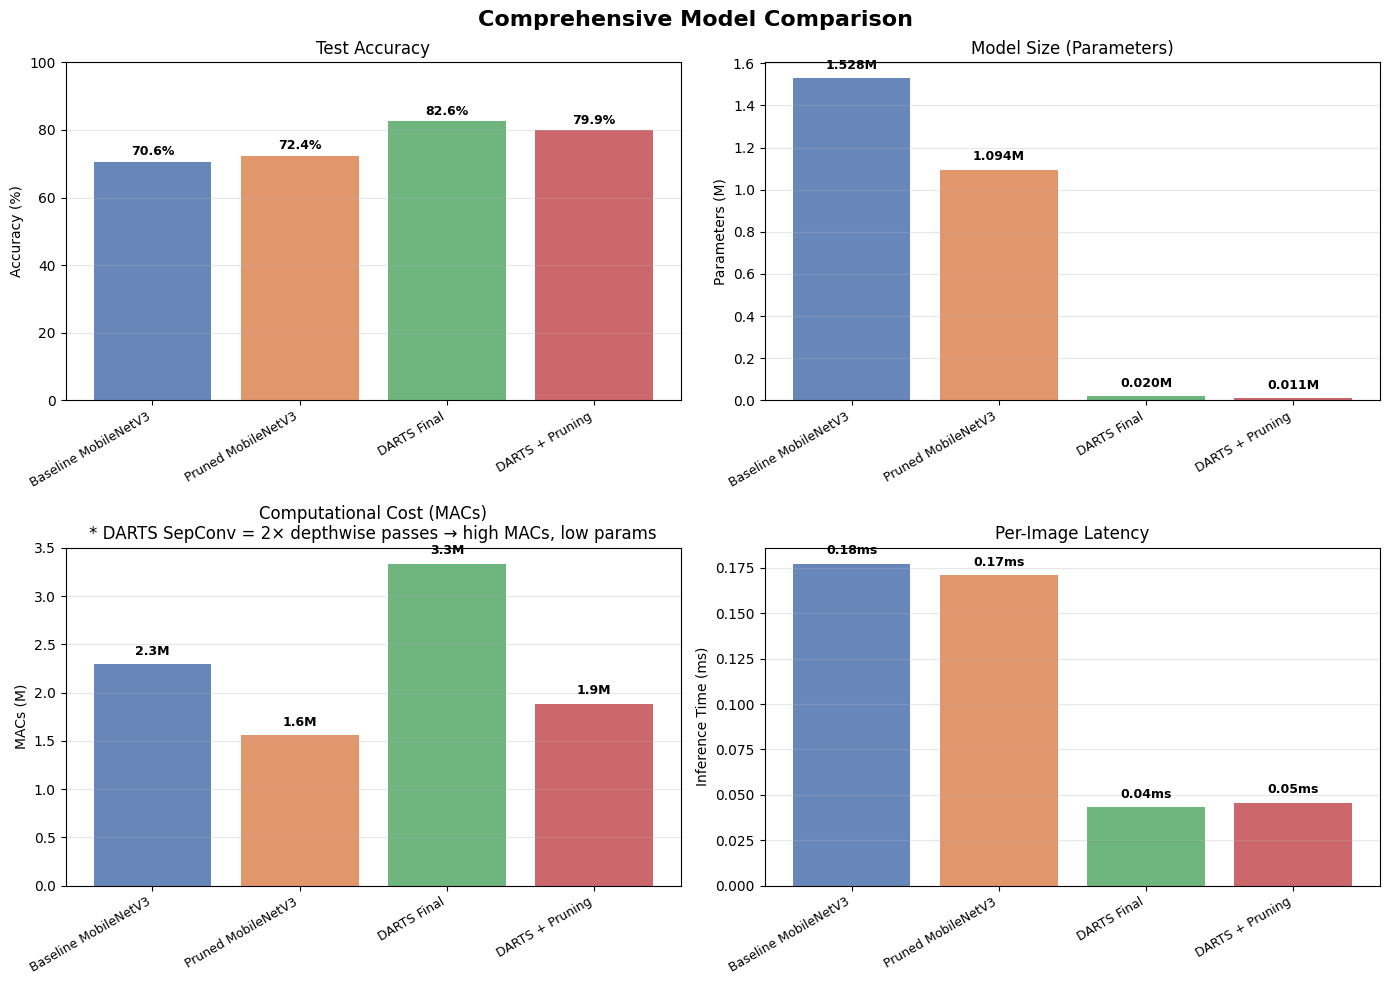

✅ Radar chart saved to ./results/radar_chart.png


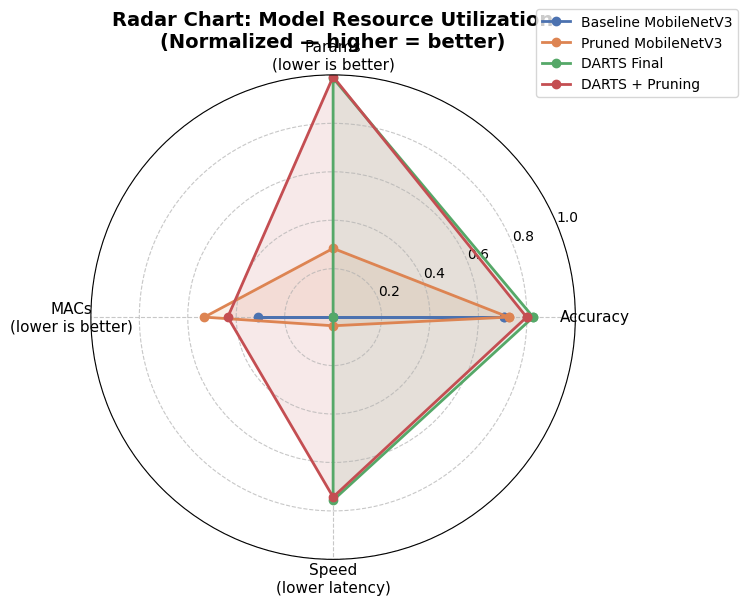

✅ Figure saved to ./results/efficiency_frontier.png


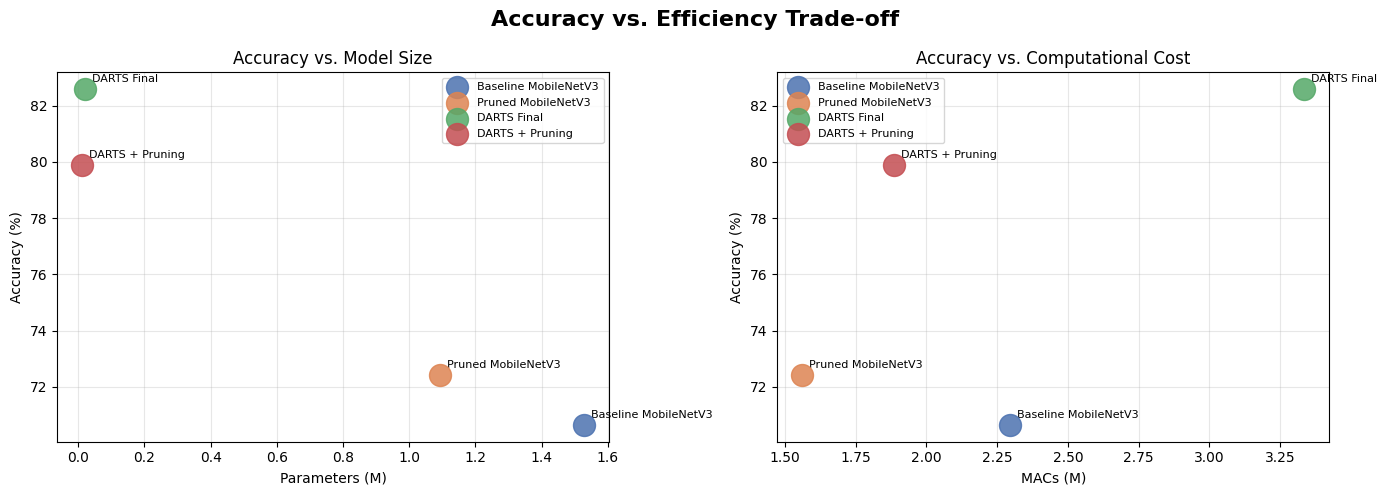


✅ ALL VISUALIZATIONS COMPLETED!
📊 Models shown: 4/4
   - baseline
   - pruned
   - darts_final
   - darts_pruned


In [ ]:
"""
Cell 11: Comprehensive Model Comparison – FIXED VERSION
========================================================
FIXES:
  2. Runs pruning + finetuning when .pth files are missing — no fallback
     to baseline (which caused Baseline == Pruned identical results).
  3. Passes trainloader so finetuning always has data.
  4. Runs at module level (no __main__ guard) for Colab/Jupyter.
  5. DARTS MACs note added to table and chart title.
"""

import torch
import torch.nn as nn
import os
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict


# ============================================================================
# COMPARISON — ALWAYS PRODUCES 4 REAL, DISTINCT MODELS
# ============================================================================

def compare_all_models(config, testloader, trainloader=None):
    """
    Load and compare ALL 4 models.
    If a pruned .pth file is missing the pruning + finetuning pipeline is
    run on the spot rather than falling back to the baseline.

    Args:
        config      : Configuration object
        testloader  : Test data loader (for evaluation)
        trainloader : Full training data loader — required when any
                      finetuning needs to run (missing .pth files)

    Returns:
        all_metrics : dict with keys 'baseline', 'pruned',
                      'darts_final', 'darts_pruned'
    """
    all_metrics = {}

    print("\n" + "="*70)
    print("COMPREHENSIVE MODEL COMPARISON - ALL 4 MODELS")
    print("="*70)

    # =========================================================================
    # 1. Baseline MobileNetV3  (required — raises if missing)
    # =========================================================================
    baseline_path  = os.path.join(config.MODEL_DIR, 'baseline_mobilenetv3.pth')
    baseline_model = None

    print("\n📊 [1/4] Loading Baseline MobileNetV3...")

    if os.path.exists(baseline_path):
        try:
            baseline_model = get_mobilenet_v3(num_classes=config.NUM_CLASSES, pretrained=False)
            baseline_model.load_state_dict(
                torch.load(baseline_path, map_location=config.DEVICE)
            )
            metrics = collect_metrics(baseline_model, testloader, config, "Baseline MobileNetV3")
            all_metrics['baseline'] = metrics
            print_metrics(metrics)
            print("   ✅ Baseline loaded")
        except Exception as e:
            print(f"   ❌ ERROR: {e}")
            raise RuntimeError("Baseline model is required!")
    else:
        print(f"   ❌ ERROR: Not found at {baseline_path}")
        raise FileNotFoundError(
            "Baseline model required. Run the baseline training cell first."
        )

    # =========================================================================
    # 2. Pruned MobileNetV3
    #    Build pruned arch from baseline, then load weights or run finetuning.
    # =========================================================================
    pruned_path = os.path.join(config.MODEL_DIR, 'pruned_mobilenetv3_finetuned.pth')

    print("\n📊 [2/4] Loading Pruned MobileNetV3...")

    try:
        print("   🔨 Building pruned architecture...")
        pruned_model, masks = prune_model(baseline_model, config)

        baseline_params = sum(p.numel() for p in baseline_model.parameters())
        pruned_params   = sum(p.numel() for p in pruned_model.parameters())

        if pruned_params >= baseline_params:
            raise RuntimeError(
                f"Pruning did not reduce parameters: {pruned_params} >= {baseline_params}"
            )

        print(f"   📉 Params: {baseline_params:,} → {pruned_params:,} "
              f"({100*(1-pruned_params/baseline_params):.1f}% reduction)")

        if os.path.exists(pruned_path):
            print("   📂 Loading saved fine-tuned weights...")
            pruned_model.load_state_dict(
                torch.load(pruned_path, map_location=config.DEVICE)
            )
            print("   ✅ Loaded saved pruned model")
        else:
            print("   ⚠️  No saved pruned model — running fine-tuning now...")
            if trainloader is None:
                raise RuntimeError(
                    "trainloader required to fine-tune the pruned model.\n"
                    "Call: compare_all_models(config, testloader, trainloader=trainloader)"
                )
            pruned_model = finetune_pruned_model(
                pruned_model, trainloader, testloader, config, pruned_path
            )
            print("   ✅ Fine-tuning done — weights saved for future runs")

        metrics = collect_metrics(pruned_model, testloader, config, "Pruned MobileNetV3")
        all_metrics['pruned'] = metrics
        print_metrics(metrics)
        print("   ✅ Pruned MobileNetV3 ready")

    except Exception as e:
        print(f"   ❌ ERROR in pruned pipeline: {e}")
        import traceback; traceback.print_exc()
        raise

    # =========================================================================
    # 3. DARTS Final Network  (required — raises if missing)
    # =========================================================================
    darts_path  = os.path.join(config.MODEL_DIR, 'darts_final_network.pth')
    darts_model = None

    print("\n📊 [3/4] Loading DARTS Final Network...")

    if os.path.exists(darts_path):
        try:
            checkpoint     = torch.load(darts_path, map_location=config.DEVICE)
            darts_genotype = checkpoint['genotype']
            darts_model    = DARTSFinalNetwork(
                genotype=darts_genotype,
                init_channels=config.DARTS_INIT_CHANNELS,
                num_classes=config.NUM_CLASSES
            )
            darts_model.load_state_dict(checkpoint['state_dict'])
            metrics = collect_metrics(darts_model, testloader, config, "DARTS Final")
            all_metrics['darts_final'] = metrics
            print_metrics(metrics)
            print("   ✅ DARTS Final loaded")
        except Exception as e:
            print(f"   ❌ ERROR: {e}")
            raise RuntimeError("DARTS model is required!")
    else:
        print(f"   ❌ ERROR: Not found at {darts_path}")
        raise FileNotFoundError(
            "DARTS model required. Run the DARTS training cell first."
        )

    # =========================================================================
    # 4. DARTS + Pruning
    #    Build pruned DARTS arch, then load weights or run finetuning.
    # =========================================================================
    darts_pruned_path = os.path.join(config.MODEL_DIR, 'darts_pruned_finetuned.pth')

    print("\n📊 [4/4] Loading DARTS + Pruning...")

    try:
        print("   Attempting to rebuild pruned DARTS...")
        pruned_darts, masks_d = prune_darts_network(darts_model, config)

        darts_params        = sum(p.numel() for p in darts_model.parameters())
        pruned_darts_params = sum(p.numel() for p in pruned_darts.parameters())

        if pruned_darts_params >= darts_params:
            raise RuntimeError("DARTS pruning did not reduce parameters")

        if os.path.exists(darts_pruned_path):
            print(f"   Loading weights ({pruned_darts_params:,} params)...")
            pruned_darts.load_state_dict(
                torch.load(darts_pruned_path, map_location=config.DEVICE)
            )
            print("   ✅ Loaded saved DARTS + Pruning model")
        else:
            print("   ⚠️  No saved DARTS+Pruning model — running fine-tuning now...")
            if trainloader is None:
                raise RuntimeError(
                    "trainloader required to fine-tune the pruned DARTS model.\n"
                    "Call: compare_all_models(config, testloader, trainloader=trainloader)"
                )
            pruned_darts = finetune_pruned_darts(
                pruned_darts, trainloader, testloader, config, darts_pruned_path
            )
            print("   ✅ Fine-tuning done — weights saved for future runs")

        metrics = collect_metrics(pruned_darts, testloader, config, "DARTS + Pruning")
        all_metrics['darts_pruned'] = metrics
        print_metrics(metrics)
        print("   ✅ DARTS + Pruning ready")

    except Exception as e:
        print(f"   ❌ ERROR in DARTS+Pruning pipeline: {e}")
        import traceback; traceback.print_exc()
        raise

    # =========================================================================
    # SUMMARY
    # =========================================================================
    print("\n" + "="*70)
    print("✅ LOADED ALL 4 MODELS:")
    for key in ['baseline', 'pruned', 'darts_final', 'darts_pruned']:
        status = "✅" if key in all_metrics else "❌"
        print(f"   {status} {key}")
    print("="*70)

    return all_metrics


# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_comparison(metrics_dict, save_path=None):
    """2×2 bar chart grid: accuracy, params, MACs, latency."""
    if not metrics_dict:
        print("⚠️  No metrics to plot")
        return

    labels     = [m['label']       for m in metrics_dict.values()]
    accuracies = [m['val_acc']      for m in metrics_dict.values()]
    params     = [m['total_params'] for m in metrics_dict.values()]
    macs       = [m['macs']         for m in metrics_dict.values()]
    inf_times  = [m['inf_time_ms']  for m in metrics_dict.values()]
    colors     = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Comprehensive Model Comparison', fontsize=16, fontweight='bold')

    # 1. Accuracy
    ax   = axes[0, 0]
    bars = ax.bar(range(len(labels)), accuracies, color=colors, alpha=0.85)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Test Accuracy')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # 2. Parameters
    ax       = axes[0, 1]
    params_m = [p / 1e6 for p in params]
    bars     = ax.bar(range(len(labels)), params_m, color=colors, alpha=0.85)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Parameters (M)')
    ax.set_title('Model Size (Parameters)')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, params_m):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(params_m)*0.02,
                f'{val:.3f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # 3. MACs
    ax     = axes[1, 0]
    macs_m = [m / 1e6 for m in macs]
    bars   = ax.bar(range(len(labels)), macs_m, color=colors, alpha=0.85)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('MACs (M)')
    ax.set_title('Computational Cost (MACs)\n'
                 '* DARTS SepConv = 2× depthwise passes → high MACs, low params')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, macs_m):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(macs_m)*0.02,
                f'{val:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # 4. Inference Time
    ax   = axes[1, 1]
    bars = ax.bar(range(len(labels)), inf_times, color=colors, alpha=0.85)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Inference Time (ms)')
    ax.set_title('Per-Image Latency')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, inf_times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(inf_times)*0.02,
                f'{val:.2f}ms', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Figure saved to {save_path}")
    plt.show()


def plot_radar_chart(metrics_dict, save_path=None):
    """Radar chart with 4 axes: accuracy, params, MACs, speed."""
    if not metrics_dict:
        return

    labels     = [m['label']       for m in metrics_dict.values()]
    accuracies = np.array([m['val_acc']      for m in metrics_dict.values()])
    params     = np.array([m['total_params'] for m in metrics_dict.values()])
    macs       = np.array([m['macs']         for m in metrics_dict.values()])
    inf_times  = np.array([m['inf_time_ms']  for m in metrics_dict.values()])

    # Normalise — higher = better on every axis
    acc_norm    = accuracies / 100.0
    params_norm = 1.0 - (params    / params.max())
    macs_norm   = 1.0 - (macs      / macs.max())
    speed_norm  = 1.0 - (inf_times / inf_times.max())

    categories = ['Accuracy', 'Params\n(lower is better)',
                  'MACs\n(lower is better)', 'Speed\n(lower latency)']
    N      = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

    for idx, label in enumerate(labels):
        values = [acc_norm[idx], params_norm[idx], macs_norm[idx], speed_norm[idx]]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=label,
                color=colors[idx % len(colors)])
        ax.fill(angles, values, alpha=0.12, color=colors[idx % len(colors)])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=11)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.title('Radar Chart: Model Resource Utilization\n(Normalized — higher = better)',
              size=14, fontweight='bold', pad=20)
    plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Radar chart saved to {save_path}")
    plt.show()


def plot_efficiency_frontier(metrics_dict, save_path=None):
    """Scatter: accuracy vs params, and accuracy vs MACs."""
    if not metrics_dict:
        return

    labels     = [m['label']           for m in metrics_dict.values()]
    accuracies = [m['val_acc']          for m in metrics_dict.values()]
    params     = [m['total_params']/1e6 for m in metrics_dict.values()]
    macs       = [m['macs']/1e6         for m in metrics_dict.values()]
    colors     = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Accuracy vs. Efficiency Trade-off', fontsize=16, fontweight='bold')

    for i, label in enumerate(labels):
        ax1.scatter(params[i], accuracies[i], s=250, alpha=0.85,
                    color=colors[i % len(colors)], zorder=5, label=label)
        ax1.annotate(label, (params[i], accuracies[i]),
                     xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax1.set_xlabel('Parameters (M)')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Accuracy vs. Model Size')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    for i, label in enumerate(labels):
        ax2.scatter(macs[i], accuracies[i], s=250, alpha=0.85,
                    color=colors[i % len(colors)], zorder=5, label=label)
        ax2.annotate(label, (macs[i], accuracies[i]),
                     xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax2.set_xlabel('MACs (M)')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Accuracy vs. Computational Cost')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Figure saved to {save_path}")
    plt.show()


def generate_comparison_table(metrics_dict):

    print("\n" + "="*105)
    print("COMPREHENSIVE COMPARISON TABLE")
    print("="*105)
    print(f"{'Model':<35s} {'Accuracy':>10s} {'Params':>12s} {'MACs':>10s} "
          f"{'Latency':>10s} {'Param Reduction':>16s} {'Throughput':>12} {'Speedup':>10} {'Lat. Red.':>10}")
    print("-"*105)

    baseline_lat = None
    baseline_params = None

    # 1. UPDATED LOGIC: Extract both latency and params from the Unpruned Baseline
    for m in metrics_dict.values():
        if 'baseline' in m['label'].lower() and 'pruned' not in m['label'].lower():
            baseline_lat = m['inf_time_ms']
            baseline_params = m['total_params']
            print(f"ℹ️  Reference set to: {m['label']} (Latency: {baseline_lat:.2f} ms)")
            break

    # 2. Print the Rows
    for metrics in metrics_dict.values():
        label   = metrics['label']
        acc     = metrics['val_acc']
        params  = metrics['total_params'] / 1e6
        macs    = metrics['macs'] / 1e6
        latency = metrics['inf_time_ms']

        # Parameter Reduction Logic
        if baseline_params and metrics['total_params'] != baseline_params:
            reduction = f"{100*(1 - metrics['total_params']/baseline_params):.1f}%"
        else:
            reduction = "—"

        # Latency/Speedup Logic
        throughput = 1000.0 / latency if latency > 0 else 0

        if baseline_lat and latency > 0:
            speedup = baseline_lat / latency
            lat_red = (1 - (latency / baseline_lat)) * 100
        else:
            speedup = 1.0
            lat_red = 0.0

        print(f"{label:<35s} {acc:>9.2f}% {params:>10.3f}M {macs:>9.1f}M "
              f"{latency:>9.2f}ms {reduction:>16s} {throughput:>10.1f} FPS {speedup:>9.2f}x {lat_red:>9.1f}%")

    print("="*105)


# ============================================================================
# MAIN EXECUTION
# Runs directly in Colab/Jupyter — no __main__ guard needed
# ============================================================================

set_seed(Config.SEED)
setup_directories()

# Load data — trainloader needed if any finetuning has to run
_, _, testloader, train_dataset, _ = load_cifar10(Config)
trainloader = get_full_trainloader(train_dataset, Config)

# Run comparison; finetuning triggered automatically if .pth files are missing
metrics_dict = compare_all_models(Config, testloader, trainloader=trainloader)

if len(metrics_dict) >= 2:
    generate_comparison_table(metrics_dict)

    plot_comparison(
        metrics_dict,
        save_path=os.path.join(Config.RESULTS_DIR, 'model_comparison.png')
    )
    plot_radar_chart(
        metrics_dict,
        save_path=os.path.join(Config.RESULTS_DIR, 'radar_chart.png')
    )
    plot_efficiency_frontier(
        metrics_dict,
        save_path=os.path.join(Config.RESULTS_DIR, 'efficiency_frontier.png')
    )

    print("\n" + "="*70)
    print("✅ ALL VISUALIZATIONS COMPLETED!")
    print("="*70)
    print(f"📊 Models shown: {len(metrics_dict)}/4")
    for key in metrics_dict:
        print(f"   - {key}")
else:
    print("❌ Could not load minimum required models")

In [ ]:
# ==============================================================================
# ONNX EXPORT & INT8 QUANTIZATION CELL (V3 VERSION - FIXED)
# ==============================================================================
import torch
import torch.onnx
import os
import onnx
from google.colab import files

# Install ONNX Runtime if not already present
!pip install -q onnxruntime

import onnxruntime
from onnxruntime.quantization import quantize_dynamic, QuantType
from onnxruntime.quantization.shape_inference import quant_pre_process

ONNX_DIR = './onnx_models'
os.makedirs(ONNX_DIR, exist_ok=True)

# Static Input Shape for Edge Inference (Batch Size 1)
DUMMY_INPUT = torch.randn(1, 3, 32, 32, device='cpu')

def export_and_quantize_onnx(model, base_filename):
    """
    Exports to FP32 ONNX (Static Shapes), pre-processes, then applies INT8 Quantization.
    """
    model.eval()
    model.cpu()

    fp32_filepath = os.path.join(ONNX_DIR, f"{base_filename}_fp32.onnx")
    prep_filepath = os.path.join(ONNX_DIR, f"{base_filename}_prep.onnx")
    int8_filepath = os.path.join(ONNX_DIR, f"{base_filename}_int8.onnx")

    try:
        # STEP 1: Export Standard FP32 ONNX (STATIC SHAPES)
        torch.onnx.export(
            model, DUMMY_INPUT, fp32_filepath,
            export_params=True, opset_version=17,
            do_constant_folding=True,
            input_names=['input'], output_names=['output']
        )
        print(f"✅ Exported Standard ONNX: {base_filename}_fp32.onnx")

        # STEP 2: Pre-Process Model Shapes
        try:
            quant_pre_process(
                input_model_path=fp32_filepath,
                output_model_path=prep_filepath,
                skip_optimization=False
            )
            print(f"🧹 Pre-processed Shapes successfully.")
            model_to_quantize = prep_filepath
        except Exception as prep_e:
            print(f"⚠️ Pre-processing skipped (using standard model): {prep_e}")
            model_to_quantize = fp32_filepath

        # STEP 3: Apply Dynamic INT8 Quantization
        quantize_dynamic(
            model_input=model_to_quantize,
            model_output=int8_filepath,
            weight_type=QuantType.QUInt8
        )
        print(f"🗜️ Successfully Quantized: {base_filename}_int8.onnx")

        # STEP 4: Compare File Sizes
        fp32_size = os.path.getsize(fp32_filepath) / (1024 * 1024)
        int8_size = os.path.getsize(int8_filepath) / (1024 * 1024)
        print(f"   📊 Compression: {fp32_size:.2f} MB -> {int8_size:.2f} MB ({(1 - int8_size/fp32_size)*100:.1f}% reduction)\n")

        # Download both to your laptop
        files.download(fp32_filepath)
        files.download(int8_filepath)

    except Exception as e:
        print(f"❌ Failed processing {base_filename}: {e}\n")

# ==============================================================================
# EXECUTION SCRIPT FOR MOBILENET-V3 PIPELINE
# ==============================================================================
print("🚀 EXPORTING AND QUANTIZING MOBILENET-V3 MODELS...")

# 1. Baseline V3 Model
base_path = os.path.join(Config.MODEL_DIR, 'baseline_mobilenetv3.pth')
# Fallback in case it was saved under the old v2 name by mistake
alt_base_path = os.path.join(Config.MODEL_DIR, 'baseline_mobilenetv2.pth')
actual_path = base_path if os.path.exists(base_path) else (alt_base_path if os.path.exists(alt_base_path) else None)

if actual_path:
    print("\nProcessing Baseline V3...")
    baseline_v3 = get_mobilenet_v3(num_classes=10, pretrained=False)
    baseline_v3.load_state_dict(torch.load(actual_path, map_location='cpu'))
    export_and_quantize_onnx(baseline_v3, "baseline_v3")

# 2. Pruned V3 Model
pruned_path = os.path.join(Config.MODEL_DIR, 'pruned_mobilenetv3_finetuned.pth')
if os.path.exists(pruned_path) and actual_path:
    print("\nProcessing Pruned V3 Model...")
    # Make sure your structural pruning function name matches your V3 script!
    pruned_model_v3, _ = prune_model(baseline_v3, Config, prune_amount=Config.PRUNE_AMOUNT)
    pruned_model_v3.load_state_dict(torch.load(pruned_path, map_location='cpu'))
    export_and_quantize_onnx(pruned_model_v3, "pruned_v3")

# 3. DARTS Final Network
darts_path = os.path.join(Config.MODEL_DIR, 'darts_final_network.pth')
if os.path.exists(darts_path):
    print("\nProcessing DARTS Model...")
    checkpoint = torch.load(darts_path, map_location='cpu')
    darts = DARTSFinalNetwork(checkpoint['genotype'], 16, 10)
    darts.load_state_dict(checkpoint['state_dict'])
    export_and_quantize_onnx(darts, "darts_v3")

# 4. Pruned DARTS Final Network
pruned_darts_path = os.path.join(Config.MODEL_DIR, 'darts_pruned_finetuned.pth')
if os.path.exists(pruned_darts_path) and os.path.exists(darts_path):
    print("\nProcessing Pruned DARTS Model...")
    checkpoint = torch.load(darts_path, map_location='cpu')
    base_darts = DARTSFinalNetwork(checkpoint['genotype'], 16, 10)
    pruned_darts_model, _ = prune_darts_network(base_darts, Config)
    pruned_darts_model.load_state_dict(torch.load(pruned_darts_path, map_location='cpu'))
    export_and_quantize_onnx(pruned_darts_model, "pruned_darts_v3")

print("\n🎉 All V3 models exported and quantized successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 60.1 MB/s eta 0:00:00
🚀 EXPORTING AND QUANTIZING MOBILENET-V3 MODELS...

Processing Baseline V3...


W0420 05:35:34.110000 2627 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0420 05:35:34.920000 2627 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0420 05:35:34.922000 2627 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -

[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:68: adapt: Asserti

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 68 of general pattern rewrite rules.
✅ Exported Standard ONNX: baseline_v3_fp32.onnx
🧹 Pre-processed Shapes successfully.
🗜️ Successfully Quantized: baseline_v3_int8.onnx
   📊 Compression: 0.28 MB -> 1.56 MB (-458.0% reduction)



...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 All V3 models exported and quantized successfully!


VISUAL COMPARISON

🚀 Running Inference Pipeline for: V3
📤 UPLOAD IMAGE


Saving Cat_November_2010-1a.jpg to Cat_November_2010-1a.jpg

Model           | Prediction   | Conf (%)   | Acc (%)  | F1 (%)  
-------------------------------------------------------------------------------------
Baseline        | bird         | 99.99      | 63.40    | 62.03   
Pruned          | cat          | 51.97      | 71.73    | 71.57   
DARTS           | cat          | 75.60      | 82.59    | 82.54   
DARTS+Prune     | cat          | 73.81      | 79.89    | 79.79   


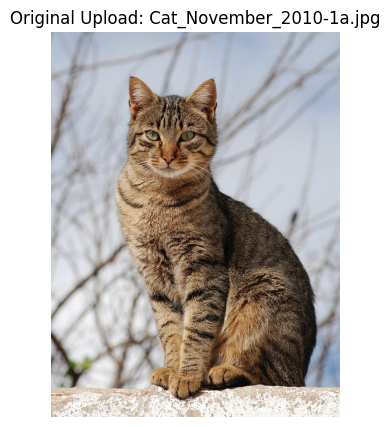

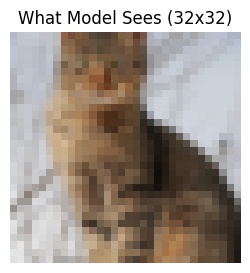

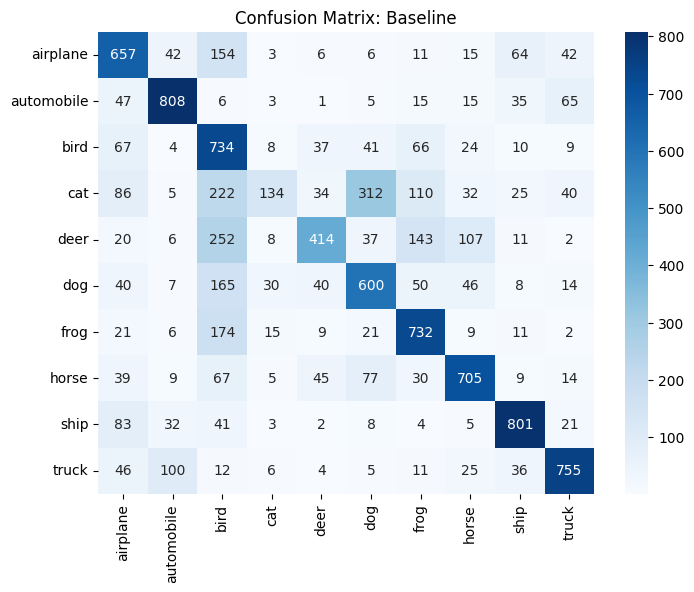

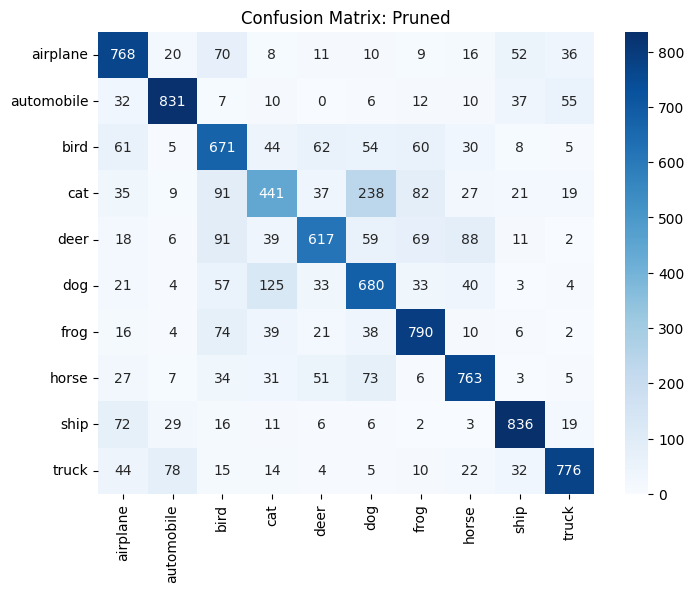

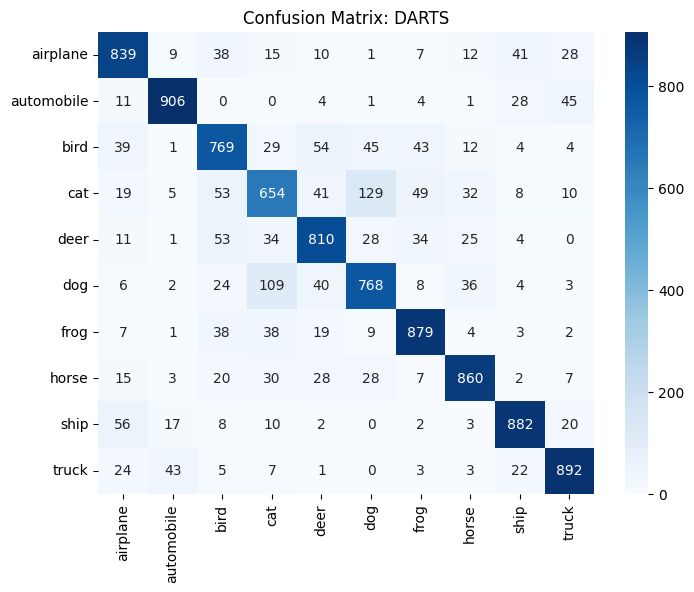

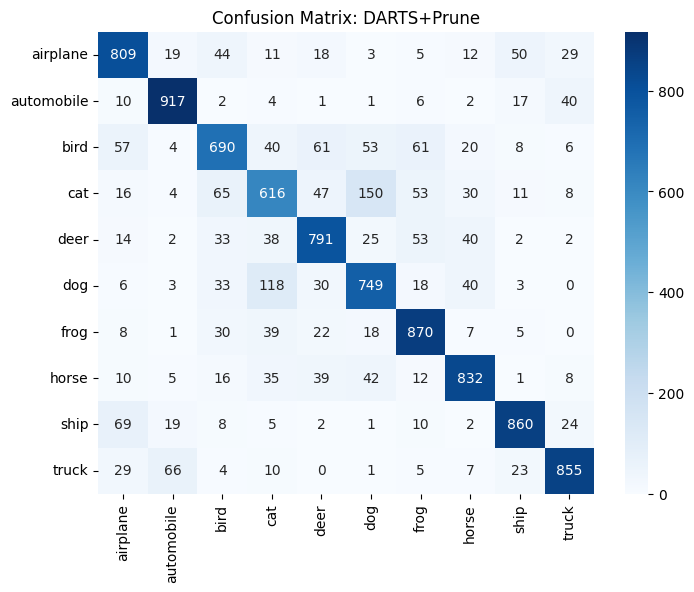

In [ ]:
import os
import copy
import time
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms, models, datasets
from google.colab import files
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Standard CIFAR-10 stats for Normalization
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

# ==============================================================================
# SMART PREPROCESSING (Ensures Accuracy)
# ==============================================================================
smart_inference_transform = transforms.Compose([
    transforms.Resize(40),                # Resize smaller edge to 40 to maintain ratio
    transforms.CenterCrop(32),            # Crop a 32x32 square from the center (focus on subject)
    transforms.ToTensor(),                # Convert to tensor
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD) # Match training color distribution
])

# Standard test transform for batch evaluation
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# ==============================================================================
# DARTS ARCHITECTURE (Required for Loading)
# ==============================================================================
class SepConv(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride, padding, affine=True):
        super().__init__()
        self.op = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_in, kernel_size, stride, padding, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_in, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_in, affine=affine),
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_in, kernel_size, 1, padding, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_out, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_out, affine=affine),
        )
    def forward(self, x): return self.op(x)

class PoolBN(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride, padding):
        super().__init__()
        self.op = nn.Sequential(
            nn.MaxPool2d(kernel_size, stride=stride, padding=padding),
            nn.Conv2d(C_in, C_out, 1, bias=False),
            nn.BatchNorm2d(C_out)
        )
    def forward(self, x): return self.op(x)

def get_ops(C_in, C_out, stride):
    return {
        'sep_3x3': SepConv(C_in, C_out, 3, stride, 1),
        'sep_5x5': SepConv(C_in, C_out, 5, stride, 2),
        'max_pool': PoolBN(C_in, C_out, 3, stride, 1),
        'identity': nn.Identity(),
    }

class DARTSFinalNetwork(nn.Module):
    def __init__(self, genotype, init_channels=16, num_classes=10):
        super().__init__()
        self.genotype = genotype
        self.stem = nn.Sequential(
            nn.Conv2d(3, init_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(init_channels),
            nn.ReLU(inplace=True)
        )
        layers = []
        C_curr = init_channels
        for i, op_name in enumerate(genotype):
            stride = 2 if i in [len(genotype)//3, 2*len(genotype)//3] else 1
            C_out = C_curr if stride == 1 else C_curr * 2
            layers.append(get_ops(C_curr, C_out, stride)[op_name])
            C_curr = C_out
        self.layers = nn.Sequential(*layers)
        self.global_pooling = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(C_curr, num_classes)

    def forward(self, x):
        x = self.stem(x); x = self.layers(x)
        x = self.global_pooling(x); x = x.view(x.size(0), -1)
        return self.classifier(x)

# ==============================================================================
# RECONSTRUCTION ENGINE
# ==============================================================================
def set_module_by_path(model, path, new_module):
    parts = path.split('.')
    parent = model
    for part in parts[:-1]:
        parent = parent[int(part)] if part.isdigit() else getattr(parent, part)
    final_part = parts[-1]
    if final_part.isdigit(): parent[int(final_part)] = new_module
    else: setattr(parent, final_part, new_module)

def force_rebuild_sequential(base_model, state_dict):
    replacements = {}
    prev_out_channels = 3
    for name, module in base_model.named_modules():
        w_key = f"{name}.weight"
        if w_key in state_dict:
            ckpt_w = state_dict[w_key]
            if isinstance(module, nn.Conv2d):
                new_out = ckpt_w.shape[0]
                k_h = ckpt_w.shape[2] if len(ckpt_w.shape) == 4 else module.kernel_size[0]
                k_w = ckpt_w.shape[3] if len(ckpt_w.shape) == 4 else module.kernel_size[1]
                is_dw = (ckpt_w.shape[1] == 1 and new_out > 1 and k_h > 1)
                new_in = new_out if is_dw else prev_out_channels
                if "stem.0" in name: new_in = 3
                replacements[name] = nn.Conv2d(new_in, new_out, (k_h, k_w), module.stride, module.padding, module.dilation, groups=new_in if is_dw else 1, bias=module.bias is not None)
                prev_out_channels = new_out
            elif isinstance(module, nn.BatchNorm2d):
                replacements[name] = nn.BatchNorm2d(ckpt_w.shape[0])
            elif isinstance(module, nn.Linear):
                replacements[name] = nn.Linear(prev_out_channels, ckpt_w.shape[0])
                # THE FIX: We must update the tracker for the next Linear layer!
                prev_out_channels = ckpt_w.shape[0]

    for path, mod in replacements.items():
        set_module_by_path(base_model, path, mod)
    base_model.load_state_dict(state_dict, strict=False)
    return base_model

def safe_load_model(path, arch_family='v2', num_classes=10):
    if not os.path.exists(path):
        print(f"⚠️ Model missing at: {path}")
        return None

    ckpt = torch.load(path, map_location='cpu')
    sd = ckpt['state_dict'] if (isinstance(ckpt, dict) and 'state_dict' in ckpt) else ckpt

    # 1. Check if it's a DARTS model
    if any("stem" in k for k in sd.keys()):
        genotype = ['sep_3x3', 'max_pool', 'max_pool', 'max_pool', 'sep_5x5', 'sep_5x5']
        base = DARTSFinalNetwork(genotype, 16, num_classes)

    # 2. Check if it's MobileNetV3
    elif arch_family == 'v3':
        # Note: Change to mobilenet_v3_large if you used the large variant
        base = models.mobilenet_v3_small(num_classes=num_classes)

    # 3. Check if it's EfficientNet-B0
    elif arch_family == 'efficientnet':
        base = models.efficientnet_b0(num_classes=num_classes)

    # 4. Default to MobileNetV2
    else:
        base = models.mobilenet_v2(num_classes=num_classes)

    return force_rebuild_sequential(base, sd).to(DEVICE)

# ==============================================================================
# EVALUATION & VISUALIZATION
# ==============================================================================
def plot_full_report(all_metrics, img_orig, img_tensor, img_name):
    # 1. Display Input
    plt.figure(figsize=(5, 5))
    plt.imshow(img_orig)
    plt.title(f"Original Upload: {img_name}")
    plt.axis('off'); plt.show()

    # 2. Display Model View
    plt.figure(figsize=(3, 3))
    view_img = img_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
    view_img = np.clip(view_img * CIFAR_STD + CIFAR_MEAN, 0, 1)
    plt.imshow(view_img)
    plt.title("What Model Sees (32x32)")
    plt.axis('off'); plt.show()

    # 3. Confusion Matrices
    for name, metrics in all_metrics.items():
        plt.figure(figsize=(8, 6))
        sns.heatmap(metrics['cm'], annot=True, fmt='d', cmap='Blues', xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES)
        plt.title(f"Confusion Matrix: {name}")
        plt.show()

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    # ==========================================
    # TOGGLE ARCHITECTURE HERE ('v2', 'v3', or 'efficientnet')
    # ==========================================
    TARGET_ARCH = "v3"

    testloader = torch.utils.data.DataLoader(datasets.CIFAR10("./data", train=False, download=True, transform=test_transform), batch_size=128)

    # Automatically select the correct paths based on the toggle
    paths_dict = {
        "v2": {
            "Baseline": "models/baseline_mobilenetv2.pth",
            "Pruned": "models/pruned_mobilenetv2_finetuned.pth",
            "DARTS": "models/darts_final_network.pth",
            "DARTS+Prune": "models/darts_pruned_finetuned.pth"
        },
        "v3": {
            "Baseline": "models/baseline_mobilenetv3.pth",
            "Pruned": "models/pruned_mobilenetv3_finetuned.pth",
            "DARTS": "models/darts_final_network.pth",
            "DARTS+Prune": "models/darts_pruned_finetuned.pth"
        },
        "efficientnet": {
            "Baseline": "models/baseline_eff.pth",
            "Pruned": "models/pruned_eff_finetuned.pth",
            "DARTS": "models/darts_eff_final.pth",
            "DARTS+Prune": "models/darts_pruned_eff_finetuned.pth"
        }
    }

    model_paths = paths_dict.get(TARGET_ARCH, paths_dict["v2"])

    print(f"🚀 Running Inference Pipeline for: {TARGET_ARCH.upper()}")
    print("📤 UPLOAD IMAGE")
    uploaded = files.upload()

    if uploaded:
        img_name = list(uploaded.keys())[0]
        img_orig = Image.open(img_name).convert('RGB')
        img_tensor = smart_inference_transform(img_orig).unsqueeze(0).to(DEVICE)

        all_results = {}
        print("\n" + "="*85)
        print(f"{'Model':<15} | {'Prediction':<12} | {'Conf (%)':<10} | {'Acc (%)':<8} | {'F1 (%)':<8}")
        print("-" * 85)

        for name, path in model_paths.items():
            model = safe_load_model(path, arch_family=TARGET_ARCH)

            if model:
                model.eval()
                # Single Image Prediction
                output = model(img_tensor)
                prob = torch.nn.functional.softmax(output, dim=1)
                conf, pred = torch.max(prob, 1)

                # Full Evaluation for metrics (Global Acc & F1)
                preds_list, labels_list = [], []
                with torch.no_grad():
                    for imgs, labels in testloader:
                        out = model(imgs.to(DEVICE))
                        preds_list.extend(out.argmax(1).cpu().numpy())
                        labels_list.extend(labels.numpy())

                acc = (np.array(preds_list) == np.array(labels_list)).mean() * 100
                f1 = f1_score(labels_list, preds_list, average='weighted') * 100
                cm = confusion_matrix(labels_list, preds_list)

                all_results[name] = {'cm': cm}
                print(f"{name:<15} | {CIFAR10_CLASSES[pred.item()]:<12} | {conf.item()*100:<10.2f} | {acc:<8.2f} | {f1:<8.2f}")

        # Generate the visual report
        plot_full_report(all_results, img_orig, img_tensor, img_name)

🚀 Running Inference Pipeline for: V3
📤 UPLOAD IMAGE


Saving dog (1).jpeg to dog (1).jpeg

Model           | Prediction   | Conf (%)   | Acc (%)  | F1 (%)  
-------------------------------------------------------------------------------------
Baseline        | dog          | 99.74      | 63.40    | 62.03   
Pruned          | dog          | 82.36      | 71.73    | 71.57   
DARTS           | dog          | 99.21      | 82.59    | 82.54   
DARTS+Prune     | dog          | 79.53      | 79.89    | 79.79   


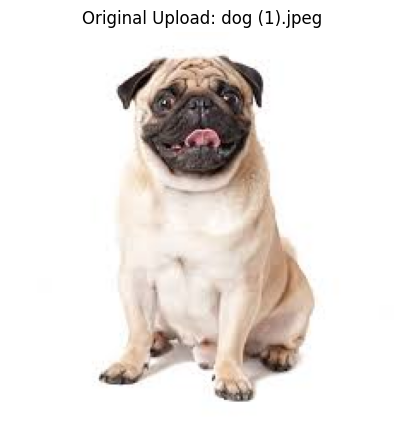

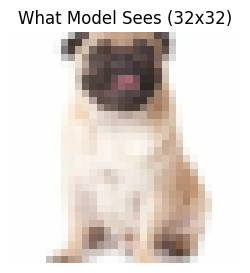

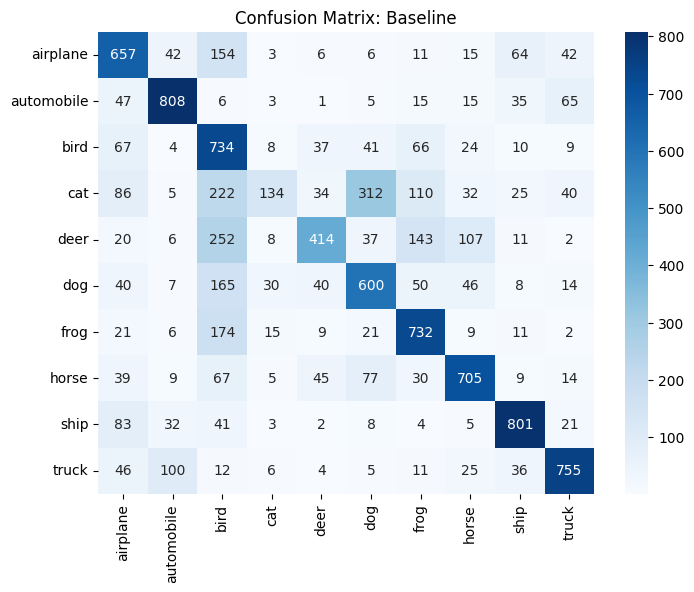

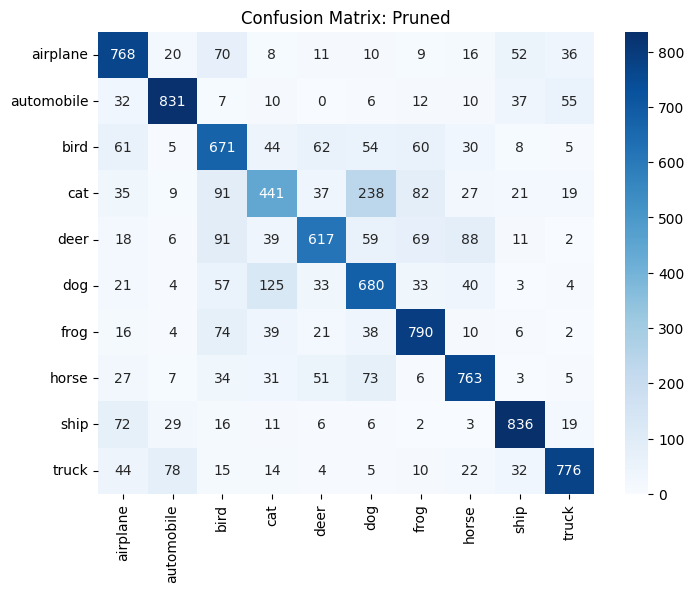

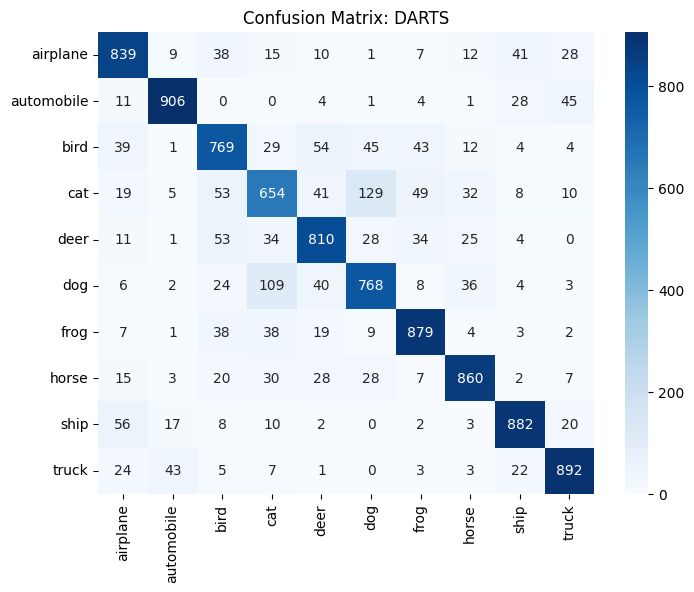

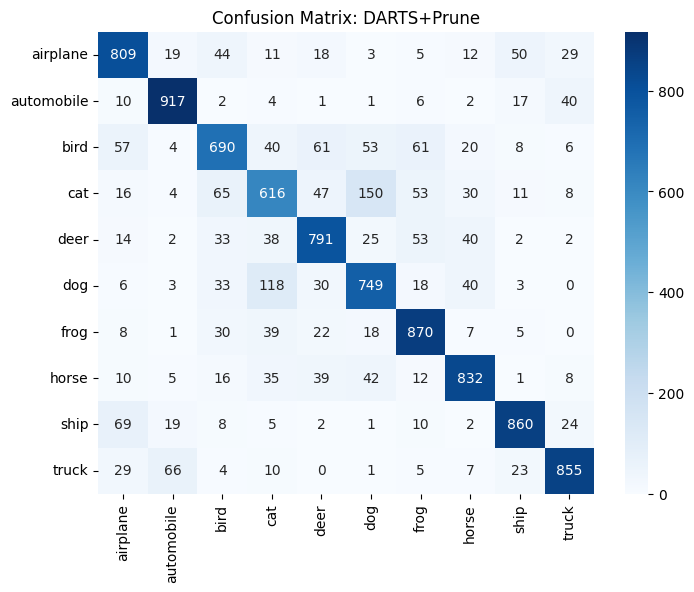

In [ ]:
import os
import copy
import time
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms, models, datasets
from google.colab import files
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Standard CIFAR-10 stats for Normalization
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

# ==============================================================================
# SMART PREPROCESSING (Ensures Accuracy)
# ==============================================================================
smart_inference_transform = transforms.Compose([
    transforms.Resize(40),                # Resize smaller edge to 40 to maintain ratio
    transforms.CenterCrop(32),            # Crop a 32x32 square from the center (focus on subject)
    transforms.ToTensor(),                # Convert to tensor
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD) # Match training color distribution
])

# Standard test transform for batch evaluation
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# ==============================================================================
# DARTS ARCHITECTURE (Required for Loading)
# ==============================================================================
class SepConv(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride, padding, affine=True):
        super().__init__()
        self.op = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_in, kernel_size, stride, padding, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_in, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_in, affine=affine),
            nn.ReLU(inplace=False),
            nn.Conv2d(C_in, C_in, kernel_size, 1, padding, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_out, 1, padding=0, bias=False),
            nn.BatchNorm2d(C_out, affine=affine),
        )
    def forward(self, x): return self.op(x)

class PoolBN(nn.Module):
    def __init__(self, C_in, C_out, kernel_size, stride, padding):
        super().__init__()
        self.op = nn.Sequential(
            nn.MaxPool2d(kernel_size, stride=stride, padding=padding),
            nn.Conv2d(C_in, C_out, 1, bias=False),
            nn.BatchNorm2d(C_out)
        )
    def forward(self, x): return self.op(x)

def get_ops(C_in, C_out, stride):
    return {
        'sep_3x3': SepConv(C_in, C_out, 3, stride, 1),
        'sep_5x5': SepConv(C_in, C_out, 5, stride, 2),
        'max_pool': PoolBN(C_in, C_out, 3, stride, 1),
        'identity': nn.Identity(),
    }

class DARTSFinalNetwork(nn.Module):
    def __init__(self, genotype, init_channels=16, num_classes=10):
        super().__init__()
        self.genotype = genotype
        self.stem = nn.Sequential(
            nn.Conv2d(3, init_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(init_channels),
            nn.ReLU(inplace=True)
        )
        layers = []
        C_curr = init_channels
        for i, op_name in enumerate(genotype):
            stride = 2 if i in [len(genotype)//3, 2*len(genotype)//3] else 1
            C_out = C_curr if stride == 1 else C_curr * 2
            layers.append(get_ops(C_curr, C_out, stride)[op_name])
            C_curr = C_out
        self.layers = nn.Sequential(*layers)
        self.global_pooling = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(C_curr, num_classes)

    def forward(self, x):
        x = self.stem(x); x = self.layers(x)
        x = self.global_pooling(x); x = x.view(x.size(0), -1)
        return self.classifier(x)

# ==============================================================================
# RECONSTRUCTION ENGINE
# ==============================================================================
def set_module_by_path(model, path, new_module):
    parts = path.split('.')
    parent = model
    for part in parts[:-1]:
        parent = parent[int(part)] if part.isdigit() else getattr(parent, part)
    final_part = parts[-1]
    if final_part.isdigit(): parent[int(final_part)] = new_module
    else: setattr(parent, final_part, new_module)

def force_rebuild_sequential(base_model, state_dict):
    replacements = {}
    prev_out_channels = 3
    for name, module in base_model.named_modules():
        w_key = f"{name}.weight"
        if w_key in state_dict:
            ckpt_w = state_dict[w_key]
            if isinstance(module, nn.Conv2d):
                new_out = ckpt_w.shape[0]
                k_h = ckpt_w.shape[2] if len(ckpt_w.shape) == 4 else module.kernel_size[0]
                k_w = ckpt_w.shape[3] if len(ckpt_w.shape) == 4 else module.kernel_size[1]
                is_dw = (ckpt_w.shape[1] == 1 and new_out > 1 and k_h > 1)
                new_in = new_out if is_dw else prev_out_channels
                if "stem.0" in name: new_in = 3
                replacements[name] = nn.Conv2d(new_in, new_out, (k_h, k_w), module.stride, module.padding, module.dilation, groups=new_in if is_dw else 1, bias=module.bias is not None)
                prev_out_channels = new_out
            elif isinstance(module, nn.BatchNorm2d):
                replacements[name] = nn.BatchNorm2d(ckpt_w.shape[0])
            elif isinstance(module, nn.Linear):
                replacements[name] = nn.Linear(prev_out_channels, ckpt_w.shape[0])
                # THE FIX: We must update the tracker for the next Linear layer!
                prev_out_channels = ckpt_w.shape[0]

    for path, mod in replacements.items():
        set_module_by_path(base_model, path, mod)
    base_model.load_state_dict(state_dict, strict=False)
    return base_model

def safe_load_model(path, arch_family='v2', num_classes=10):
    if not os.path.exists(path):
        print(f"⚠️ Model missing at: {path}")
        return None

    ckpt = torch.load(path, map_location='cpu')
    sd = ckpt['state_dict'] if (isinstance(ckpt, dict) and 'state_dict' in ckpt) else ckpt

    # 1. Check if it's a DARTS model
    if any("stem" in k for k in sd.keys()):
        genotype = ['sep_3x3', 'max_pool', 'max_pool', 'max_pool', 'sep_5x5', 'sep_5x5']
        base = DARTSFinalNetwork(genotype, 16, num_classes)

    # 2. Check if it's MobileNetV3
    elif arch_family == 'v3':
        # Note: Change to mobilenet_v3_large if you used the large variant
        base = models.mobilenet_v3_small(num_classes=num_classes)

    # 3. Check if it's EfficientNet-B0
    elif arch_family == 'efficientnet':
        base = models.efficientnet_b0(num_classes=num_classes)

    # 4. Default to MobileNetV2
    else:
        base = models.mobilenet_v2(num_classes=num_classes)

    return force_rebuild_sequential(base, sd).to(DEVICE)

# ==============================================================================
# EVALUATION & VISUALIZATION
# ==============================================================================
def plot_full_report(all_metrics, img_orig, img_tensor, img_name):
    # 1. Display Input
    plt.figure(figsize=(5, 5))
    plt.imshow(img_orig)
    plt.title(f"Original Upload: {img_name}")
    plt.axis('off'); plt.show()

    # 2. Display Model View
    plt.figure(figsize=(3, 3))
    view_img = img_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
    view_img = np.clip(view_img * CIFAR_STD + CIFAR_MEAN, 0, 1)
    plt.imshow(view_img)
    plt.title("What Model Sees (32x32)")
    plt.axis('off'); plt.show()

    # 3. Confusion Matrices
    for name, metrics in all_metrics.items():
        plt.figure(figsize=(8, 6))
        sns.heatmap(metrics['cm'], annot=True, fmt='d', cmap='Blues', xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES)
        plt.title(f"Confusion Matrix: {name}")
        plt.show()

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================
if __name__ == "__main__":
    # ==========================================
    # TOGGLE ARCHITECTURE HERE ('v2', 'v3', or 'efficientnet')
    # ==========================================
    TARGET_ARCH = "v3"

    testloader = torch.utils.data.DataLoader(datasets.CIFAR10("./data", train=False, download=True, transform=test_transform), batch_size=128)

    # Automatically select the correct paths based on the toggle
    paths_dict = {
        "v2": {
            "Baseline": "models/baseline_mobilenetv2.pth",
            "Pruned": "models/pruned_mobilenetv2_finetuned.pth",
            "DARTS": "models/darts_final_network.pth",
            "DARTS+Prune": "models/darts_pruned_finetuned.pth"
        },
        "v3": {
            "Baseline": "models/baseline_mobilenetv3.pth",
            "Pruned": "models/pruned_mobilenetv3_finetuned.pth",
            "DARTS": "models/darts_final_network.pth",
            "DARTS+Prune": "models/darts_pruned_finetuned.pth"
        },
        "efficientnet": {
            "Baseline": "models/baseline_eff.pth",
            "Pruned": "models/pruned_eff_finetuned.pth",
            "DARTS": "models/darts_eff_final.pth",
            "DARTS+Prune": "models/darts_pruned_eff_finetuned.pth"
        }
    }

    model_paths = paths_dict.get(TARGET_ARCH, paths_dict["v2"])

    print(f"🚀 Running Inference Pipeline for: {TARGET_ARCH.upper()}")
    print("📤 UPLOAD IMAGE")
    uploaded = files.upload()

    if uploaded:
        img_name = list(uploaded.keys())[0]
        img_orig = Image.open(img_name).convert('RGB')
        img_tensor = smart_inference_transform(img_orig).unsqueeze(0).to(DEVICE)

        all_results = {}
        print("\n" + "="*85)
        print(f"{'Model':<15} | {'Prediction':<12} | {'Conf (%)':<10} | {'Acc (%)':<8} | {'F1 (%)':<8}")
        print("-" * 85)

        for name, path in model_paths.items():
            model = safe_load_model(path, arch_family=TARGET_ARCH)

            if model:
                model.eval()
                # Single Image Prediction
                output = model(img_tensor)
                prob = torch.nn.functional.softmax(output, dim=1)
                conf, pred = torch.max(prob, 1)

                # Full Evaluation for metrics (Global Acc & F1)
                preds_list, labels_list = [], []
                with torch.no_grad():
                    for imgs, labels in testloader:
                        out = model(imgs.to(DEVICE))
                        preds_list.extend(out.argmax(1).cpu().numpy())
                        labels_list.extend(labels.numpy())

                acc = (np.array(preds_list) == np.array(labels_list)).mean() * 100
                f1 = f1_score(labels_list, preds_list, average='weighted') * 100
                cm = confusion_matrix(labels_list, preds_list)

                all_results[name] = {'cm': cm}
                print(f"{name:<15} | {CIFAR10_CLASSES[pred.item()]:<12} | {conf.item()*100:<10.2f} | {acc:<8.2f} | {f1:<8.2f}")

        # Generate the visual report
        plot_full_report(all_results, img_orig, img_tensor, img_name)